<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 07 - Diffusion Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Diffusion Models

Stable Diffusion, DALL·E, Imagen and the video models all generate in the same strange way. They start from pure Gaussian noise and remove it, little by little, in tens to a thousand small steps. Every step is done by the same network, trained for one simple job: **look at a noisy input and predict the noise in it**. The whole training objective is a mean squared error.

Why does that work, and why is the loss so simple? A **diffusion model** has a fixed **forward process** that destroys the data by adding a little Gaussian noise $T$ times, and a learned **reverse process** that undoes one small step at a time. Undoing a small step is easy: it is close to a Gaussian, so the network only has to predict its mean. In this lab we build every piece from scratch on 2-D points, check the key formulas numerically, and then train a small U-Net on MNIST digits.

**Contents**

1. The data and the forward process
2. Jumping to any $t$: the closed form, checked numerically
3. The reverse step: the posterior and the loss
4. A noise predictor for 2-D points
5. Sampling: ancestral DDPM
6. Denoising is score estimation; Langevin dynamics
7. DDIM: deterministic sampling with fewer steps
8. Classifier-free guidance
9. MNIST with a mini U-Net
10. Summary and exercises

This lab goes with the slides *Extra 7 · Diffusion models* and uses the same notation. It assumes MLPs, CNNs and the PyTorch training loop, and the ELBO of variational autoencoders (Extra 3). It runs on a CPU in about 7 minutes with 4 threads (the MNIST U-Net takes more than half of it); a GPU is optional.

**Notation**

| Symbol | Meaning |
|---|---|
| $\mathbf{x}_0$ | a data point (a 2-D point, an image), on the scale of the noise |
| $\mathbf{x}_t$, $t = 1, \dots, T$ | the data after $t$ noising steps; $T = 1000$ |
| $\beta_t$ | variance of the noise added at step $t$ (the **noise schedule**) |
| $\alpha_t = 1 - \beta_t$, $\ \bar\alpha_t = \prod_{s=1}^{t} \alpha_s$ | signal kept by one step, and after $t$ steps |
| $\boldsymbol\epsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ | standard Gaussian noise |
| $q(\mathbf{x}_t \mid \mathbf{x}_{t-1})$, $q(\mathbf{x}_t \mid \mathbf{x}_0)$ | forward process: one step, and $t$ steps at once (fixed, no parameters) |
| $p_\theta(\mathbf{x}_{t-1} \mid \mathbf{x}_t)$ | reverse process (learned) |
| $\tilde{\boldsymbol\mu}_t$, $\tilde\beta_t$ | mean and variance of the true posterior $q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0)$ |
| $\boldsymbol\epsilon_\theta(\mathbf{x}_t, t)$ | the network: its estimate of the noise in $\mathbf{x}_t$ |
| $\hat{\mathbf{x}}_0$ | the clean data predicted from $\mathbf{x}_t$ |
| $\mathrm{SNR}(t) = \bar\alpha_t / (1 - \bar\alpha_t)$ | signal-to-noise ratio at step $t$ |
| $\nabla_{\mathbf{x}} \log p_t(\mathbf{x})$ | the **score** of $p_t$, the distribution of $\mathbf{x}_t$ |
| $c$, $\varnothing$, $w$ | condition (a class, a text), "no condition", guidance scale |

In [1]:
import math, time, copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| CPU threads:", torch.get_num_threads())
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | torchvision 0.27.0+cu130 | CPU threads: 4


## 1. The data and the forward process

**Data.** Three spiral arms in the plane: 4000 training points and 2000 held-out points. Each point remembers its arm (0, 1 or 2), which only section 8 uses. We divide by the standard deviation so that the data have unit variance, like the noise $\boldsymbol\epsilon$. The forward process ends at $\mathcal{N}(\mathbf{0}, \mathbf{I})$, so the data and the noise must live on the same scale; images are scaled to $[-1, 1]$ for the same reason (section 9).

In [2]:
def make_spiral(n, rng, noise=0.06):
    """Three spiral arms. Returns the points (n, 2) and the arm (0, 1 or 2) of each point."""
    arm = rng.integers(0, 3, n)
    s = rng.uniform(0, 1, n)                                  # position along the arm, 0 = centre
    r = 0.25 + 1.75 * s
    angle = 2 * np.pi * arm / 3 + 2.6 * s
    X = np.stack([r * np.cos(angle), r * np.sin(angle)], axis=1)
    return X + noise * rng.normal(size=(n, 2)), arm

rng = np.random.default_rng(0)
X_np, y_np = make_spiral(4000, rng)                           # training set
Xte_np, yte_np = make_spiral(2000, rng)                       # held-out set, to judge the samples
scale = X_np.std()
X_np, Xte_np = X_np / scale, Xte_np / scale                   # one common scale: unit variance, like the noise
X_tr, y_tr = torch.tensor(X_np, dtype=torch.float32), torch.tensor(y_np)
X_te, y_te = torch.tensor(Xte_np, dtype=torch.float32), torch.tensor(yte_np)
ARM = np.array(["tab:blue", "tab:orange", "tab:green"])

print(f"training points: {len(X_tr)}, held-out points: {len(X_te)}, points per arm: {np.bincount(y_np)}")
print(f"after scaling: mean {X_np.mean(0).round(3)}, std per coordinate {X_np.std(0).round(3)} (expected about 0 and 1)")

training points: 4000, held-out points: 2000, points per arm: [1317 1331 1352]
after scaling: mean [0.005 0.006], std per coordinate [1.007 0.993] (expected about 0 and 1)


**One forward step** adds a little noise and shrinks the signal a little:

$$ q(\mathbf{x}_t \mid \mathbf{x}_{t-1}) = \mathcal{N}\big(\sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\ \beta_t\mathbf{I}\big), \qquad \text{that is}\quad \mathbf{x}_t = \sqrt{1-\beta_t}\,\mathbf{x}_{t-1} + \sqrt{\beta_t}\,\boldsymbol\epsilon . $$

Why the factor $\sqrt{1-\beta_t}$: if $\mathbf{x}_{t-1}$ has variance 1 per coordinate, $\mathbf{x}_t$ has variance $(1-\beta_t)\cdot 1 + \beta_t = 1$. The process is **variance preserving**: the cloud never blows up, it only loses its shape.

**Noise schedules.** DDPM (Ho et al., 2020) uses $T = 1000$ and a **linear** schedule, $\beta_t$ from $10^{-4}$ to $0.02$. The **cosine** schedule (Nichol and Dhariwal, 2021) defines $\bar\alpha_t$ directly: $\bar\alpha_t = f(t)/f(0)$ with $f(t) = \cos^2\!\big(\frac{t/T + s}{1+s}\cdot\frac{\pi}{2}\big)$ and $s = 0.008$. What matters is how much signal is left, $\bar\alpha_t$, or the **signal-to-noise ratio** $\mathrm{SNR}(t) = \bar\alpha_t/(1-\bar\alpha_t)$ (section 2 shows why).

In code every schedule array is indexed by $t = 0, \dots, T$ with $\beta_0 = 0$ and $\bar\alpha_0 = 1$, so that `abar[t]` is $\bar\alpha_t$.

   t    beta_t   abar_t (linear)   abar_t (cosine)   SNR (linear)   SNR (cosine)
    1  0.00010           0.99990           0.99996           9999      2.422e+04
  100  0.00207           0.89702           0.97209           8.71          34.83
  250  0.00506           0.52409           0.84701          1.101          5.536
  500  0.01004           0.07859           0.49384        0.08529         0.9757
  750  0.01502           0.00335           0.14427       0.003362         0.1686
 1000  0.02000           0.00004           0.00000      4.036e-05      2.429e-09
abar_t falls below 0.5 (SNR below 1) at t = 260 (linear) and t = 497 (cosine)
fraction of steps with SNR < 0.01 (almost pure noise): linear 0.33, cosine 0.06


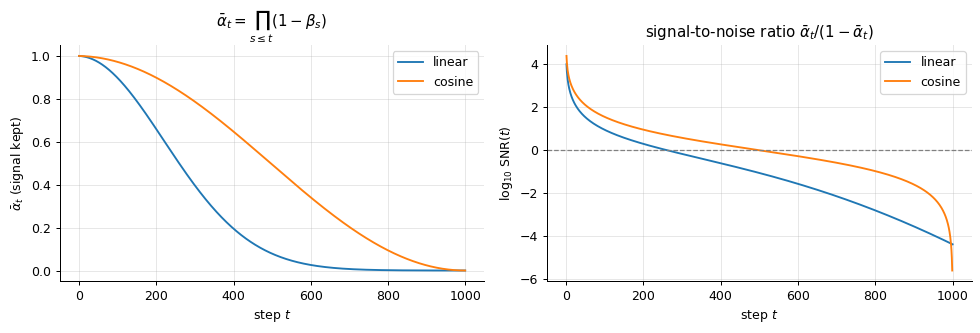

In [3]:
T = 1000

def linear_betas(T, beta_1=1e-4, beta_T=0.02):
    """DDPM's schedule. Index t = 0..T; beta[0] = 0 is a convention (no step), so beta[t] is beta_t."""
    return np.concatenate([[0.0], np.linspace(beta_1, beta_T, T)])

def cosine_betas(T, s=0.008):
    """Nichol and Dhariwal (2021): abar_t = f(t) / f(0) with f(t) = cos^2((t/T + s) / (1 + s) * pi/2)."""
    t = np.arange(T + 1)
    f = np.cos((t / T + s) / (1 + s) * np.pi / 2) ** 2
    abar = f / f[0]
    return np.concatenate([[0.0], np.clip(1 - abar[1:] / abar[:-1], 0, 0.999)])

beta = linear_betas(T)
alpha = 1 - beta
abar = np.cumprod(alpha)                     # abar[t] = alpha_1 * ... * alpha_t, abar[0] = 1
abar_cos = np.cumprod(1 - cosine_betas(T))
snr, snr_cos = abar / (1 - abar + 1e-300), abar_cos / (1 - abar_cos + 1e-300)

print("   t    beta_t   abar_t (linear)   abar_t (cosine)   SNR (linear)   SNR (cosine)")
for t in [1, 100, 250, 500, 750, 1000]:
    print(f"{t:5d}  {beta[t]:.5f}   {abar[t]:15.5f}   {abar_cos[t]:15.5f}   {snr[t]:12.4g}   {snr_cos[t]:12.4g}")
half_lin, half_cos = np.argmax(abar < 0.5), np.argmax(abar_cos < 0.5)
print(f"abar_t falls below 0.5 (SNR below 1) at t = {half_lin} (linear) and t = {half_cos} (cosine)")
print(f"fraction of steps with SNR < 0.01 (almost pure noise): linear {np.mean(snr[1:] < 0.01):.2f}, cosine {np.mean(snr_cos[1:] < 0.01):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ts = np.arange(T + 1)
axes[0].plot(ts, abar, label="linear"); axes[0].plot(ts, abar_cos, label="cosine")
axes[0].set_xlabel("step $t$"); axes[0].set_ylabel(r"$\bar\alpha_t$ (signal kept)"); axes[0].legend()
axes[0].set_title(r"$\bar\alpha_t=\prod_{s\leq t}(1-\beta_s)$")
axes[1].plot(ts[1:], np.log10(snr[1:]), label="linear"); axes[1].plot(ts[1:-1], np.log10(snr_cos[1:-1]), label="cosine")
axes[1].axhline(0, color="gray", lw=1, ls="--")
axes[1].set_xlabel("step $t$"); axes[1].set_ylabel(r"$\log_{10}\,\mathrm{SNR}(t)$"); axes[1].legend()
axes[1].set_title(r"signal-to-noise ratio $\bar\alpha_t/(1-\bar\alpha_t)$")
plt.tight_layout(); plt.show()

**Things to notice.**
- With the linear schedule $\bar\alpha_t$ falls below 0.5 (SNR below 1) at $t = 260$, and a third of the steps (33%) have an SNR below 0.01: they see almost pure noise and are nearly wasted. The cosine schedule reaches SNR 1 only at $t = 497$ and spends only 6% of the steps in almost pure noise. It destroys information more evenly, which helps most for small images (Nichol and Dhariwal measured better likelihoods on 32×32 and 64×64 images).
- At $t = 1000$ both schedules leave almost nothing: $\bar\alpha_{1000} = 4\cdot10^{-5}$ for the linear one, so $\mathbf{x}_T$ is $\mathcal{N}(\mathbf{0}, \mathbf{I})$ up to a signal of amplitude $\sqrt{\bar\alpha_T} = 0.006$. That is what lets the reverse process start from pure noise.
- The rest of the lab uses the linear schedule, as DDPM does. Below we iterate the one-step update 1000 times on the spiral.

t =    0: mean [0.005 0.006], std [1.008 0.993], signal kept sqrt(abar_t) = 1.000
t =   50: mean [0.007 0.006], std [1.013 0.99 ], signal kept sqrt(abar_t) = 0.985
t =  100: mean [0.002 0.001], std [1.015 0.99 ], signal kept sqrt(abar_t) = 0.947
t =  200: mean [0.001 0.011], std [1.019 1.   ], signal kept sqrt(abar_t) = 0.812
t =  400: mean [-0.002  0.005], std [0.972 1.026], signal kept sqrt(abar_t) = 0.442
t = 1000: mean [-0.017  0.009], std [1.009 1.022], signal kept sqrt(abar_t) = 0.006


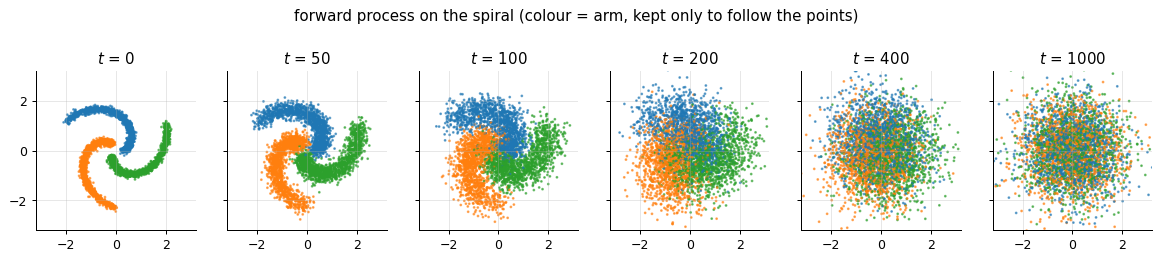

In [4]:
def forward_step(x, t, gen):
    """One forward step: x_t = sqrt(1 - beta_t) x_{t-1} + sqrt(beta_t) eps."""
    return math.sqrt(1 - beta[t]) * x + math.sqrt(beta[t]) * torch.randn(x.shape, generator=gen)

gen = torch.Generator().manual_seed(1)
snap_t = [0, 50, 100, 200, 400, 1000]
x = X_tr.clone()
snaps = {0: x.clone()}
for t in range(1, T + 1):                    # iterate the one-step process 1000 times
    x = forward_step(x, t, gen)
    if t in snap_t:
        snaps[t] = x.clone()

for t in snap_t:
    print(f"t = {t:4d}: mean {snaps[t].mean(0).numpy().round(3)}, std {snaps[t].std(0).numpy().round(3)}, "
          f"signal kept sqrt(abar_t) = {math.sqrt(abar[t]):.3f}")

fig, axes = plt.subplots(1, 6, figsize=(16, 3.0), sharex=True, sharey=True)
for ax, t in zip(axes, snap_t):
    ax.scatter(*snaps[t].T, s=1.5, c=ARM[y_np], alpha=0.6)
    ax.set_title(f"$t$ = {t}"); ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
fig.suptitle("forward process on the spiral (colour = arm, kept only to follow the points)", y=1.02)
plt.show()

**What just happened?** We applied the one-step update 1000 times to the 4000 points. The cloud keeps a mean close to 0 and a standard deviation close to 1 at every step (1.01 and 1.02 at $t = 1000$): the process is variance preserving. But its shape dissolves. At $t = 100$ the arms are blurred, at $t = 400$ only a faint trace is left ($\sqrt{\bar\alpha_{400}} = 0.44$ of the signal), and at $t = 1000$ it is a round Gaussian blob, whatever the data were. Generation will run this film backwards.

## 2. Jumping to any $t$: the closed form, checked numerically

Training needs $\mathbf{x}_t$ for a random $t$. Iterating $t$ steps every time would be slow; fortunately there is a closed form.

**Claim.** $\displaystyle q(\mathbf{x}_t \mid \mathbf{x}_0) = \mathcal{N}\big(\sqrt{\bar\alpha_t}\,\mathbf{x}_0,\ (1-\bar\alpha_t)\mathbf{I}\big)$, that is, $\ \mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon\ $ with $\boldsymbol\epsilon \sim \mathcal{N}(\mathbf{0},\mathbf{I})$.

*Proof by induction.* It holds for $t = 1$, since $\bar\alpha_1 = \alpha_1 = 1 - \beta_1$. Assume $\mathbf{x}_{t-1} = \sqrt{\bar\alpha_{t-1}}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_{t-1}}\,\boldsymbol\epsilon'$. One more step, with fresh noise $\boldsymbol\epsilon''$:

$$ \mathbf{x}_t = \sqrt{\alpha_t}\,\mathbf{x}_{t-1} + \sqrt{1-\alpha_t}\,\boldsymbol\epsilon'' = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \underbrace{\sqrt{\alpha_t(1-\bar\alpha_{t-1})}\,\boldsymbol\epsilon' + \sqrt{1-\alpha_t}\,\boldsymbol\epsilon''}_{\text{two independent Gaussians}} . $$

A sum of independent zero-mean Gaussians is a zero-mean Gaussian whose variance is the sum of the variances: $\alpha_t(1-\bar\alpha_{t-1}) + 1 - \alpha_t = 1 - \alpha_t\bar\alpha_{t-1} = 1 - \bar\alpha_t$. $\square$

So the mean shrinks like $\sqrt{\bar\alpha_t}$ and the variance grows like $1 - \bar\alpha_t$. For data of unit variance, $\mathbf{x}_t$ contains signal power $\bar\alpha_t$ and noise power $1-\bar\alpha_t$: their ratio, the SNR, is the natural clock of the process.

**Numerical check.** Start 100,000 independent chains at the scalar $x_0 = 2$, apply the one-step update 1000 times, and compare the empirical mean and variance with the formula. The asserts allow 5 standard errors.

    t   mean (iterated)  sqrt(abar_t) x0   var (iterated)   1 - abar_t
    1           1.9999           1.9999          0.00010      0.00010
   10           1.9983           1.9981          0.00189      0.00189
  100           1.8932           1.8942          0.10259      0.10298


  250           1.4465           1.4479          0.47678      0.47591


  500           0.5645           0.5607          0.91787      0.92141


 1000           0.0118           0.0127          0.99989      0.99996
closed form confirmed: mean sqrt(abar_t) x0 and variance 1 - abar_t at every checked t

spiral at t = 200: covariance after 200 small steps
[[1.038 0.002]
 [0.002 1.001]]
covariance after one jump with the closed form
[[1.034 0.012]
 [0.012 0.983]]
expected: abar_t Cov(x_0) + (1 - abar_t) I =
[[1.01  0.004]
 [0.004 0.99 ]]


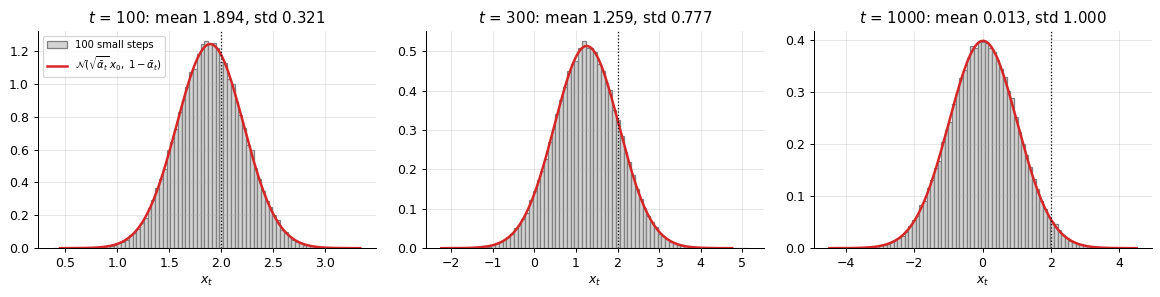

In [5]:
x0 = 2.0
n_chains = 100_000
check_t = [1, 10, 100, 250, 500, 1000]
gen = torch.Generator().manual_seed(2)
x = torch.full((n_chains,), x0, dtype=torch.float64)
kept = {}
print("    t   mean (iterated)  sqrt(abar_t) x0   var (iterated)   1 - abar_t")
for t in range(1, T + 1):                                     # 1000 one-step updates of 100,000 chains
    x = math.sqrt(1 - beta[t]) * x + math.sqrt(beta[t]) * torch.randn(n_chains, generator=gen, dtype=torch.float64)
    if t in (100, 300, 1000):
        kept[t] = x.numpy().copy()
    if t in check_t:
        m, v = x.mean().item(), x.var().item()
        m_th, v_th = math.sqrt(abar[t]) * x0, 1 - abar[t]
        print(f"{t:5d}   {m:14.4f}   {m_th:14.4f}   {v:14.5f}   {v_th:10.5f}")
        assert abs(m - m_th) < 5 * math.sqrt(v_th / n_chains)            # 5 standard errors of the mean
        assert abs(v - v_th) < 5 * v_th * math.sqrt(2 / n_chains)        # 5 standard errors of the variance
print("closed form confirmed: mean sqrt(abar_t) x0 and variance 1 - abar_t at every checked t")

# the same check in 2-D on the spiral: iterated snapshot of section 1 vs one jump with the closed form
t = 200
gen = torch.Generator().manual_seed(3)
jump = math.sqrt(abar[t]) * X_tr + math.sqrt(1 - abar[t]) * torch.randn(X_tr.shape, generator=gen)
print(f"\nspiral at t = {t}: covariance after 200 small steps\n{np.cov(snaps[t].numpy().T)}")
print(f"covariance after one jump with the closed form\n{np.cov(jump.numpy().T)}")
print(f"expected: abar_t Cov(x_0) + (1 - abar_t) I =\n{abar[t] * np.cov(X_np.T) + (1 - abar[t]) * np.eye(2)}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, t in zip(axes, kept):
    m, s = math.sqrt(abar[t]) * x0, math.sqrt(1 - abar[t])
    grid = np.linspace(m - 4.5 * s, m + 4.5 * s, 300)
    ax.hist(kept[t], bins=80, density=True, color="lightgray", edgecolor="gray", label=f"{t} small steps")
    ax.plot(grid, np.exp(-(grid - m) ** 2 / (2 * s * s)) / (s * math.sqrt(2 * math.pi)), "C3", lw=2,
            label=r"$\mathcal{N}(\sqrt{\bar\alpha_t}\,x_0,\;1-\bar\alpha_t)$")
    ax.axvline(x0, color="k", ls=":", lw=1)
    ax.set_title(f"$t$ = {t}: mean {m:.3f}, std {s:.3f}"); ax.set_xlabel("$x_t$")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**What just happened?** The iterated chains match the closed form at every checked step. At $t = 100$ the mean is 1.8932 against $2\sqrt{\bar\alpha_{100}} = 1.8942$ and the variance 0.1026 against $1 - \bar\alpha_{100} = 0.1030$; at $t = 500$, 0.5645 against 0.5607 and 0.918 against 0.921. The differences are within the sampling error of 100,000 chains, and the histograms sit on the Gaussian density. In 2-D, 200 small steps and one jump give the same covariance up to the sampling error of 4000 points (about ±0.02): 1.038 and 1.034 on the first coordinate, against the expected 1.010.

From now on we never iterate the forward process: we jump.

## 3. The reverse step: the posterior and the loss

To generate we need the reverse step $q(\mathbf{x}_{t-1} \mid \mathbf{x}_t)$. By Bayes it involves $q(\mathbf{x}_{t-1})$, the distribution of the noised data, which we do not know: the reverse step is intractable. Two facts save us.

1. **Small steps are almost Gaussian.** When $\beta_t$ is small, the reverse of a small Gaussian step is itself close to a Gaussian (Feller, 1949). So we model it as $p_\theta(\mathbf{x}_{t-1}\mid\mathbf{x}_t) = \mathcal{N}\big(\boldsymbol\mu_\theta(\mathbf{x}_t, t),\ \sigma_t^2\mathbf{I}\big)$ and only learn the mean.
2. **Given $\mathbf{x}_0$, the reverse step is exactly Gaussian.** By Bayes, $q(\mathbf{x}_{t-1} \mid \mathbf{x}_t, \mathbf{x}_0) \propto q(\mathbf{x}_t \mid \mathbf{x}_{t-1})\, q(\mathbf{x}_{t-1} \mid \mathbf{x}_0)$, a product of two Gaussians in $\mathbf{x}_{t-1}$:

$$ q(\mathbf{x}_{t-1}\mid\mathbf{x}_t,\mathbf{x}_0) = \mathcal{N}\big(\tilde{\boldsymbol\mu}_t,\ \tilde\beta_t\mathbf{I}\big),\qquad
\tilde{\boldsymbol\mu}_t = \frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t}\,\mathbf{x}_0 + \frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}\,\mathbf{x}_t,\qquad
\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\,\beta_t . $$

*Proof (precisions add).* As a function of $\mathbf{x}_{t-1}$, $q(\mathbf{x}_t\mid\mathbf{x}_{t-1}) \propto \exp\!\big(-\|\mathbf{x}_t - \sqrt{\alpha_t}\,\mathbf{x}_{t-1}\|^2/2\beta_t\big)$ is a Gaussian with mean $\mathbf{x}_t/\sqrt{\alpha_t}$ and precision $\alpha_t/\beta_t$. The prior $q(\mathbf{x}_{t-1}\mid\mathbf{x}_0)$ has mean $\sqrt{\bar\alpha_{t-1}}\,\mathbf{x}_0$ and precision $1/(1-\bar\alpha_{t-1})$. A product of two Gaussian densities is a Gaussian whose precision is the sum of the precisions,

$$ \frac{\alpha_t}{\beta_t} + \frac{1}{1-\bar\alpha_{t-1}} = \frac{\alpha_t(1-\bar\alpha_{t-1}) + \beta_t}{\beta_t(1-\bar\alpha_{t-1})} = \frac{1-\bar\alpha_t}{\beta_t(1-\bar\alpha_{t-1})} = \frac{1}{\tilde\beta_t}, $$

and whose mean is the precision-weighted average of the two means, $\tilde\beta_t\big(\frac{\sqrt{\alpha_t}}{\beta_t}\mathbf{x}_t + \frac{\sqrt{\bar\alpha_{t-1}}}{1-\bar\alpha_{t-1}}\mathbf{x}_0\big)$, which simplifies to $\tilde{\boldsymbol\mu}_t$. $\square$

**With the noise instead of $\mathbf{x}_0$.** Substituting $\mathbf{x}_0 = (\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon)/\sqrt{\bar\alpha_t}$ gives

$$ \tilde{\boldsymbol\mu}_t = \frac{1}{\sqrt{\alpha_t}}\Big(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol\epsilon\Big). $$

At sampling time $\mathbf{x}_t$ is known; only the noise $\boldsymbol\epsilon$ is not. So the network will predict it.

We check the three formulas: against the textbook Gaussian conditioning of the joint law of $(\mathbf{x}_{t-1}, \mathbf{x}_t)$ (whose covariance is $\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})$), by Monte Carlo (sample many pairs and keep those with $x_t$ close to a given value), and in the $\boldsymbol\epsilon$ form.

check 1 passed: the formulas equal the Gaussian conditioning of (x_{t-1}, x_t) | x_0 at t = 2, 10, 100, 500, 1000
check 2 (t = 100, x_t = 1.6, 12955 pairs kept): mean 1.6070 vs formula 1.6076,  std 0.0448 vs formula 0.0451
check 3 passed: mu~_t(x_t, x_0) = (x_t - beta_t / sqrt(1 - abar_t) eps) / sqrt(alpha_t)
t =  10: x_t = 1.955, prior 1.998 ± 0.040, likelihood 1.955 ± 0.017, posterior 1.961 ± 0.0154  (beta~_t / beta_t = 0.853)
t = 100: x_t = 1.573, prior 1.896 ± 0.318, likelihood 1.575 ± 0.046, posterior 1.581 ± 0.0451  (beta~_t / beta_t = 0.982)
t = 500: x_t = -0.399, prior 0.564 ± 0.959, likelihood -0.401 ± 0.101, posterior -0.391 ± 0.1002  (beta~_t / beta_t = 0.999)


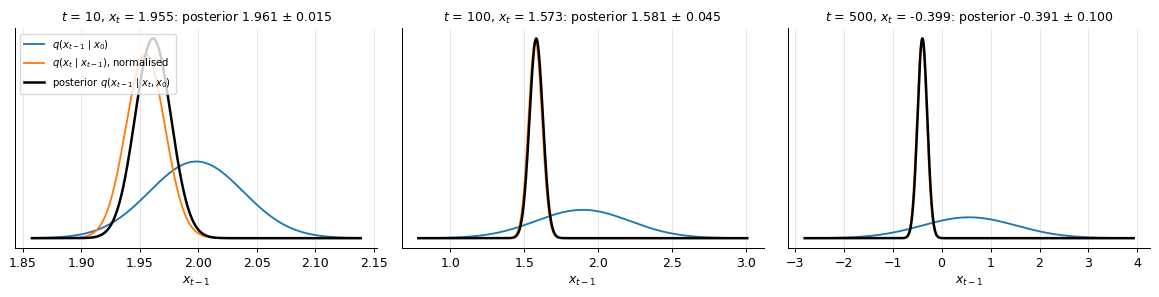

In [6]:
def posterior(t, x0, xt):
    """Mean and variance of q(x_{t-1} | x_t, x_0)."""
    var = (1 - abar[t - 1]) / (1 - abar[t]) * beta[t]
    mean = (math.sqrt(abar[t - 1]) * beta[t] / (1 - abar[t])) * x0 \
         + (math.sqrt(alpha[t]) * (1 - abar[t - 1]) / (1 - abar[t])) * xt
    return mean, var

x0 = 2.0
# check 1: Gaussian conditioning of the joint law of (x_{t-1}, x_t) given x_0
for t in [2, 10, 100, 500, 1000]:
    m1, m2 = math.sqrt(abar[t - 1]) * x0, math.sqrt(abar[t]) * x0
    V1, V2, C = 1 - abar[t - 1], 1 - abar[t], math.sqrt(alpha[t]) * (1 - abar[t - 1])   # Cov(x_{t-1}, x_t)
    xt = 0.7
    mean, var = posterior(t, x0, xt)
    assert np.isclose(mean, m1 + C / V2 * (xt - m2)) and np.isclose(var, V1 - C ** 2 / V2)
print("check 1 passed: the formulas equal the Gaussian conditioning of (x_{t-1}, x_t) | x_0 at t = 2, 10, 100, 500, 1000")

# check 2: Monte Carlo. Sample (x_{t-1}, x_t) pairs and keep those with x_t close to 1.6
t, xt_val = 100, 1.6
gen = torch.Generator().manual_seed(4)
n = 4_000_000
x_prev = math.sqrt(abar[t - 1]) * x0 + math.sqrt(1 - abar[t - 1]) * torch.randn(n, generator=gen, dtype=torch.float64)
x_t = math.sqrt(alpha[t]) * x_prev + math.sqrt(beta[t]) * torch.randn(n, generator=gen, dtype=torch.float64)
sel = (x_t - xt_val).abs() < 0.002
mean, var = posterior(t, x0, xt_val)
print(f"check 2 (t = {t}, x_t = {xt_val}, {int(sel.sum())} pairs kept): "
      f"mean {x_prev[sel].mean():.4f} vs formula {mean:.4f},  std {x_prev[sel].std():.4f} vs formula {math.sqrt(var):.4f}")
assert abs(x_prev[sel].mean().item() - mean) < 0.002 and abs(x_prev[sel].std().item() / math.sqrt(var) - 1) < 0.03

# check 3: the same mean written with the noise eps instead of x_0
gen = torch.Generator().manual_seed(5)
for t in [2, 100, 1000]:
    x0v, eps = torch.randn(5, generator=gen, dtype=torch.float64), torch.randn(5, generator=gen, dtype=torch.float64)
    xt = math.sqrt(abar[t]) * x0v + math.sqrt(1 - abar[t]) * eps
    mean_eps = (xt - beta[t] / math.sqrt(1 - abar[t]) * eps) / math.sqrt(alpha[t])
    assert torch.allclose(posterior(t, x0v, xt)[0], mean_eps)
print("check 3 passed: mu~_t(x_t, x_0) = (x_t - beta_t / sqrt(1 - abar_t) eps) / sqrt(alpha_t)")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
def gauss(g, m, v):
    return np.exp(-(g - m) ** 2 / (2 * v)) / math.sqrt(2 * math.pi * v)
for ax, t in zip(axes, [10, 100, 500]):
    xt = math.sqrt(abar[t]) * x0 - math.sqrt(1 - abar[t])            # one standard deviation below the mean
    pm, pv = math.sqrt(abar[t - 1]) * x0, 1 - abar[t - 1]               # q(x_{t-1} | x_0)
    lm, lv = xt / math.sqrt(alpha[t]), beta[t] / alpha[t]                # q(x_t | x_{t-1}) as a function of x_{t-1}
    qm, qv = posterior(t, x0, xt)
    lo, hi = min(pm - 3.5 * math.sqrt(pv), lm - 4 * math.sqrt(lv)), max(pm + 3.5 * math.sqrt(pv), lm + 4 * math.sqrt(lv))
    g = np.linspace(lo, hi, 600)
    ax.plot(g, gauss(g, pm, pv), label=r"$q(x_{t-1}\mid x_0)$")
    ax.plot(g, gauss(g, lm, lv), label=r"$q(x_t\mid x_{t-1})$, normalised")
    ax.plot(g, gauss(g, qm, qv), "k", lw=2, label=r"posterior $q(x_{t-1}\mid x_t,x_0)$")
    ax.set_title(f"$t$ = {t}, $x_t$ = {xt:.3f}: posterior {qm:.3f} ± {math.sqrt(qv):.3f}", fontsize=10)
    ax.set_xlabel("$x_{t-1}$"); ax.set_yticks([])
    print(f"t = {t:3d}: x_t = {xt:.3f}, prior {pm:.3f} ± {math.sqrt(pv):.3f}, likelihood {lm:.3f} ± {math.sqrt(lv):.3f}, "
          f"posterior {qm:.3f} ± {math.sqrt(qv):.4f}  (beta~_t / beta_t = {qv / beta[t]:.3f})")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**What just happened?**
- The three checks pass. The Monte Carlo check kept 12,955 of 4 million pairs with $x_t \approx 1.6$ at $t = 100$: their $x_{t-1}$ has mean 1.6070 and standard deviation 0.0448, against 1.6076 and 0.0451 from the formula.
- The figure shows the two factors and their product. At $t = 10$ the prior (±0.040) and the likelihood (±0.017) have comparable widths, and the posterior is a compromise: 1.961 ± 0.015, between 1.955 and 1.998. From $t = 100$ on the prior is much wider than the likelihood and the posterior is almost the likelihood: $\mathbf{x}_{t-1} \approx \mathbf{x}_t/\sqrt{\alpha_t}$, with a standard deviation close to $\sqrt{\beta_t}$ ($\tilde\beta_t/\beta_t$ = 0.982 at $t = 100$ and 0.999 at $t = 500$).
- One reverse step moves the point very little, and its spread is known in advance. All the network must supply is the small correction of the mean: that is why each step is easy to learn.

**The loss.** As in a VAE (Extra 3), we minimise an upper bound on $-\log p_\theta(\mathbf{x}_0)$, the negative ELBO. Here the latent variables are $\mathbf{x}_1, \dots, \mathbf{x}_T$ and the "encoder" $q$ is fixed. Written with the posteriors above, the bound has one KL term per step:

$$ -\log p_\theta(\mathbf{x}_0) \le \mathbb{E}_q\Big[\underbrace{D_{\mathrm{KL}}\big(q(\mathbf{x}_T\mid\mathbf{x}_0)\,\|\,p(\mathbf{x}_T)\big)}_{L_T\text{: no parameters}} + \sum_{t=2}^{T}\underbrace{D_{\mathrm{KL}}\big(q(\mathbf{x}_{t-1}\mid\mathbf{x}_t,\mathbf{x}_0)\,\|\,p_\theta(\mathbf{x}_{t-1}\mid\mathbf{x}_t)\big)}_{L_{t-1}} \ \underbrace{-\,\log p_\theta(\mathbf{x}_0\mid\mathbf{x}_1)}_{L_0}\Big]. $$

Both distributions in $L_{t-1}$ are Gaussians with the same covariance $\sigma_t^2\mathbf{I}$ (we choose $\sigma_t^2 = \tilde\beta_t$), so the KL is a scaled squared distance between the means: $L_{t-1} = \frac{1}{2\sigma_t^2}\|\tilde{\boldsymbol\mu}_t - \boldsymbol\mu_\theta\|^2$. Parametrise the mean in the $\boldsymbol\epsilon$ form,

$$ \boldsymbol\mu_\theta(\mathbf{x}_t, t) = \frac{1}{\sqrt{\alpha_t}}\Big(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol\epsilon_\theta(\mathbf{x}_t, t)\Big), $$

and $\mathbf{x}_t$ cancels in the difference of the means:

$$ L_{t-1} = \lambda_t\,\big\|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon,\ t)\big\|^2,\qquad \lambda_t = \frac{\beta_t^2}{2\sigma_t^2\,\alpha_t\,(1-\bar\alpha_t)} . $$

Ho et al. (2020) found that dropping the weight gives better samples. The **simple loss** is a plain denoising regression:

$$ L_{\text{simple}} = \mathbb{E}_{t\sim\mathcal{U}\{1,\dots,T\},\ \mathbf{x}_0,\ \boldsymbol\epsilon}\Big[\big\|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon,\ t)\big\|^2\Big]. $$

How different is it from the ELBO? We compute $\lambda_t$.

t =    2: lambda_t = 0.5997
t =   10: lambda_t = 0.0864
t =  100: lambda_t = 0.0103
t =  500: lambda_t = 0.0055
t = 1000: lambda_t = 0.0102
ratio lambda_2 / lambda_1000 = 59: the ELBO cares most about the small, almost noise-free steps


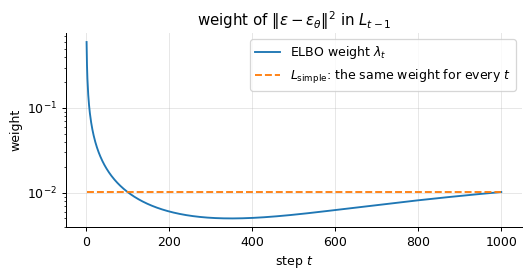

In [7]:
# weight of ||eps - eps_theta||^2 in the ELBO term L_{t-1}, with sigma_t^2 = beta~_t
tt = np.arange(2, T + 1)
sig2 = (1 - abar[tt - 1]) / (1 - abar[tt]) * beta[tt]
lam = beta[tt] ** 2 / (2 * sig2 * alpha[tt] * (1 - abar[tt]))
for t in [2, 10, 100, 500, 1000]:
    print(f"t = {t:4d}: lambda_t = {lam[t - 2]:.4f}")
print(f"ratio lambda_2 / lambda_1000 = {lam[0] / lam[-1]:.0f}: the ELBO cares most about the small, almost noise-free steps")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.semilogy(tt, lam, label=r"ELBO weight $\lambda_t$")
ax.semilogy(tt, np.full_like(lam, lam.mean()), "--", label=r"$L_{\rm simple}$: the same weight for every $t$")
ax.set_xlabel("step $t$"); ax.set_ylabel("weight"); ax.legend(); ax.set_title(r"weight of $\|\epsilon-\epsilon_\theta\|^2$ in $L_{t-1}$")
plt.tight_layout(); plt.show()

**Interpretation.** The ELBO weight $\lambda_t$ is 0.60 at $t = 2$ and about 0.01 from $t = 100$ on: 59 times more weight on the first steps, where the noise is tiny and only fine details change. $L_{\text{simple}}$ gives every step the same weight, so compared with the ELBO it **up-weights the noisy steps**, where the network must decide the global structure. That is a better use of the network for sample quality, at the price of a slightly worse likelihood (the improved DDPM of Nichol and Dhariwal mixes the two losses).

## 4. A noise predictor for 2-D points

The network $\boldsymbol\epsilon_\theta(\mathbf{x}_t, t)$ takes a noisy point and the step $t$ and returns a 2-D vector, its estimate of the noise. One network serves every $t$, so $t$ is an input. As the positions in a transformer, the integer $t$ becomes a vector of sines and cosines at geometrically spaced frequencies, the **sinusoidal embedding**

$$ \mathrm{emb}(t) = \big(\sin(\omega_1 t), \dots, \sin(\omega_{16} t),\ \cos(\omega_1 t), \dots, \cos(\omega_{16} t)\big), \qquad \omega_k = 10000^{-(k-1)/16} , $$

which a small MLP maps to the hidden size. The body is a residual MLP (3 blocks of width 128), and the time embedding is **added at the input of every block**, so every layer knows how noisy its input is. (Concatenating the embedding to the input only is simpler, but gave visibly blurrier samples in our tests.)

Training is Algorithm 1 of DDPM:

> **repeat:** take a batch of $\mathbf{x}_0$; draw $t \sim \mathcal{U}\{1, \dots, T\}$ and $\boldsymbol\epsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$; take a gradient step on $\big\|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon,\ t)\big\|^2$.

We run 8000 steps of 512 points with Adam (learning rate $2\cdot10^{-3}$, cosine decay): under a minute on a CPU. The code already includes the class input used in section 8.

In [8]:
def time_embedding(t, dim=32):
    """Sinusoidal embedding of the step t, as the positional encoding of a transformer."""
    half = dim // 2
    freqs = torch.exp(-math.log(10_000) * torch.arange(half, device=t.device) / half)
    angles = t.float()[:, None] * freqs[None, :]
    return torch.cat([angles.sin(), angles.cos()], dim=1)

class NoisePredictor(nn.Module):
    """eps_theta(x_t, t) for 2-D points: a residual MLP; the time embedding (and the class
    embedding, if any) is added at the input of every block."""
    def __init__(self, hidden=128, n_blocks=3, n_classes=0):
        super().__init__()
        self.n_classes = n_classes
        self.inp = nn.Linear(2, hidden)
        self.temb = nn.Sequential(nn.Linear(32, hidden), nn.SiLU(), nn.Linear(hidden, hidden))
        self.cemb = nn.Embedding(n_classes + 1, hidden) if n_classes else None   # last index = "no label"
        self.blocks = nn.ModuleList([nn.Sequential(nn.SiLU(), nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, hidden))
                                     for _ in range(n_blocks)])
        self.out = nn.Sequential(nn.SiLU(), nn.Linear(hidden, 2))

    def forward(self, x, t, c=None):
        e = self.temb(time_embedding(t))
        if self.n_classes:
            e = e + self.cemb(c)
        h = self.inp(x)
        for block in self.blocks:
            h = h + block(h + e)
        return self.out(h)

abar_t = torch.tensor(abar, dtype=torch.float32)        # abar_t[t] = abar_t for t = 0..T

def train_toy(model, steps=8000, batch=512, lr=2e-3, p_uncond=0.0, seed=0):
    """Algorithm 1 of DDPM. With p_uncond > 0 the label is replaced by "no label" with that probability."""
    gen = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, steps)
    losses = []
    for step in range(steps):
        idx = torch.randint(0, len(X_tr), (batch,), generator=gen)
        x0 = X_tr[idx]
        t = torch.randint(1, T + 1, (batch,), generator=gen)          # t ~ Uniform{1, ..., T}
        eps = torch.randn(x0.shape, generator=gen)                    # eps ~ N(0, I)
        ab = abar_t[t][:, None]
        xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps                   # x_t from the closed form
        if model.n_classes:
            c = y_tr[idx].clone()
            c[torch.rand(batch, generator=gen) < p_uncond] = model.n_classes
            pred = model(xt, t, c)
        else:
            pred = model(xt, t)
        loss = F.mse_loss(pred, eps)                                  # || eps - eps_theta(x_t, t) ||^2
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        losses.append(loss.item())
    return np.array(losses)

torch.manual_seed(0)
model = NoisePredictor()
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
t0 = time.time()
losses = train_toy(model)
print(f"training: {len(losses)} steps in {time.time() - t0:.0f} s; loss first 100 steps {losses[:100].mean():.3f}, "
      f"last 500 steps {losses[-500:].mean():.3f} (predicting 0 would score 1)")

parameters: 120,450


training: 8000 steps in 46 s; loss first 100 steps 0.310, last 500 steps 0.234 (predicting 0 would score 1)


How good is the network at each $t$? We measure the noise loss on held-out points, and the error of the clean point it implies, $\hat{\mathbf{x}}_0 = (\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon_\theta)/\sqrt{\bar\alpha_t}$.

t in [   1,   51): noise loss 0.719, error of x0_hat 0.007
t in [ 201,  251): noise loss 0.562, error of x0_hat 0.389
t in [ 451,  501): noise loss 0.103, error of x0_hat 0.910
t in [ 951, 1001): noise loss 0.000, error of x0_hat 1.280


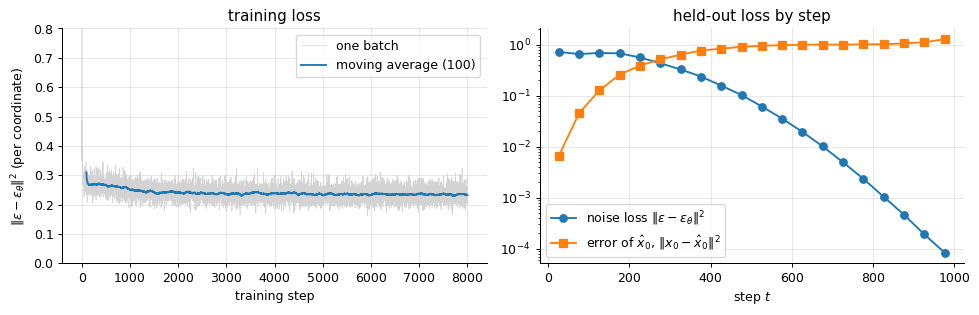

In [9]:
@torch.no_grad()
def loss_by_t(model, n=40_000, seed=6):
    """Denoising loss and error of x0_hat on held-out points, for every t."""
    gen = torch.Generator().manual_seed(seed)
    idx = torch.randint(0, len(X_te), (n,), generator=gen)
    x0 = X_te[idx]
    t = torch.randint(1, T + 1, (n,), generator=gen)
    eps = torch.randn(x0.shape, generator=gen)
    ab = abar_t[t][:, None]
    xt = ab.sqrt() * x0 + (1 - ab).sqrt() * eps
    e = model(xt, t)
    x0_hat = (xt - (1 - ab).sqrt() * e) / ab.sqrt()
    return t.numpy(), ((e - eps) ** 2).mean(1).numpy(), ((x0_hat - x0) ** 2).mean(1).numpy()

t_ev, l_eps, l_x0 = loss_by_t(model)
bins = np.linspace(1, T + 1, 21)
mid = (bins[:-1] + bins[1:]) / 2
eps_b = [l_eps[(t_ev >= a) & (t_ev < b)].mean() for a, b in zip(bins[:-1], bins[1:])]
x0_b = [l_x0[(t_ev >= a) & (t_ev < b)].mean() for a, b in zip(bins[:-1], bins[1:])]
for k in [0, 4, 9, 19]:
    print(f"t in [{bins[k]:4.0f}, {bins[k + 1]:4.0f}): noise loss {eps_b[k]:.3f}, error of x0_hat {x0_b[k]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sm = np.convolve(losses, np.ones(100) / 100, mode="valid")
axes[0].plot(losses, color="lightgray", lw=0.5, label="one batch")
axes[0].plot(np.arange(99, len(losses)), sm, "C0", label="moving average (100)")
axes[0].set_xlabel("training step"); axes[0].set_ylabel(r"$\|\epsilon-\epsilon_\theta\|^2$ (per coordinate)")
axes[0].set_ylim(0, 0.8); axes[0].legend(); axes[0].set_title("training loss")
axes[1].plot(mid, eps_b, "o-", label=r"noise loss $\|\epsilon-\epsilon_\theta\|^2$")
axes[1].plot(mid, x0_b, "s-", label=r"error of $\hat x_0$, $\|x_0-\hat x_0\|^2$")
axes[1].set_yscale("log"); axes[1].set_xlabel("step $t$"); axes[1].legend(); axes[1].set_title("held-out loss by step")
plt.tight_layout(); plt.show()

**Things to notice.**
- The loss falls fast and then plateaus at 0.234, far from 0. That is expected: the noise is not fully predictable from $\mathbf{x}_t$, because many pairs $(\mathbf{x}_0, \boldsymbol\epsilon)$ lead to the same noisy point. The best possible network predicts the average noise $\mathbb{E}[\boldsymbol\epsilon\mid\mathbf{x}_t]$, and what remains is a floor (section 6 makes this precise).
- The held-out loss depends strongly on $t$. For small $t$ the noise is hard to guess (loss 0.72 for $t < 51$): $\mathbf{x}_t$ is almost $\mathbf{x}_0$, and the tiny noise is mixed up with the thickness of the arm. But a wrong $\boldsymbol\epsilon$ barely matters there: the error on $\hat{\mathbf{x}}_0$ is only 0.007. For large $t$ it is the opposite: $\mathbf{x}_t$ is almost pure noise, so $\boldsymbol\epsilon$ is easy (loss below $10^{-3}$ for $t > 950$), while $\hat{\mathbf{x}}_0$ is a poor guess (error 1.28, worse than guessing the mean of the data, which would score about 1: dividing by $\sqrt{\bar\alpha_t}$, between 0.006 and 0.010 there, amplifies tiny errors in $\boldsymbol\epsilon_\theta$).
- The two errors are tied by $\|\mathbf{x}_0 - \hat{\mathbf{x}}_0\|^2 = \|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta\|^2/\mathrm{SNR}(t)$. Predicting $\boldsymbol\epsilon$ or $\mathbf{x}_0$ is the same problem with a different weight on each $t$ (exercise 3).

## 5. Sampling: ancestral DDPM

Generation runs the learned reverse chain from pure noise. This is Algorithm 2 of DDPM:

> $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0},\mathbf{I})$; **for** $t = T, \dots, 1$: $\ \mathbf{z} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$ if $t > 1$, else $\mathbf{z} = \mathbf{0}$; $\ \ \mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\boldsymbol\epsilon_\theta(\mathbf{x}_t, t)\Big) + \sigma_t\,\mathbf{z}$; **return** $\mathbf{x}_0$.

Each step removes a bit of the predicted noise and adds a bit of fresh noise ($\sigma_t^2 = \tilde\beta_t$ here; $\sigma_t^2 = \beta_t$ works as well). It is called **ancestral** sampling because each $\mathbf{x}_{t-1}$ is drawn given its "parent" $\mathbf{x}_t$, as in a Bayesian network. That is 1000 network calls per sample, but here all 2000 samples go through the network together.

**How to judge the samples.** With 2-D points we can compare with the held-out data directly. *Distance to the data*: the mean distance from a sample to its nearest held-out point (are the samples on the spiral?). *Distance from the data*: the mean distance from a held-out point to its nearest sample (is every part of the spiral covered?). A fresh set of 2000 real points gives the floor; 2000 Gaussian points show what bad looks like.

The function can also store the whole cloud at a few steps (`keep`), to watch the reverse process.

In [10]:
@torch.no_grad()
def predict_eps(model, x, t, c=None, w=0.0):
    """eps_theta(x_t, t), or its classifier-free guided version (section 8) when a class c is given."""
    tt = torch.full((len(x),), t, device=x.device)
    if c is None:
        return model(x, tt)
    e_c = model(x, tt, torch.full((len(x),), c, device=x.device))
    if w == 0:
        return e_c
    e_u = model(x, tt, torch.full((len(x),), model.n_classes, device=x.device))
    return (1 + w) * e_c - w * e_u

@torch.no_grad()
def sample_ddpm(model, shape, seed=0, c=None, w=0.0, keep=(), clip=None):
    """Algorithm 2 of DDPM (ancestral sampling) with sigma_t^2 = beta~_t.
    keep: steps whose x_t is stored. clip: clamp x0_hat to [-clip, clip] (used for images)."""
    gen = torch.Generator().manual_seed(seed)
    dev = next(model.parameters()).device
    x = torch.randn(shape, generator=gen).to(dev)                     # x_T ~ N(0, I)
    traj = {}
    for t in range(T, 0, -1):
        if t in keep:
            traj[t] = x.cpu().clone()
        eps = predict_eps(model, x, t, c, w)
        if clip is None:
            mean = (x - beta[t] / math.sqrt(1 - abar[t]) * eps) / math.sqrt(alpha[t])
        else:                                                         # same mean, written with a clipped x0_hat
            x0_hat = ((x - math.sqrt(1 - abar[t]) * eps) / math.sqrt(abar[t])).clamp(-clip, clip)
            mean = posterior(t, x0_hat, x)[0]
        if t > 1:
            sigma = math.sqrt((1 - abar[t - 1]) / (1 - abar[t]) * beta[t])
            x = mean + sigma * torch.randn(shape, generator=gen).to(dev)
        else:
            x = mean                                                  # no noise in the last step
    traj[0] = x.cpu().clone()
    return x.cpu(), traj

def nn_dist(A, B):
    """Mean distance from each point of A to its nearest point of B."""
    return torch.cdist(A, B).min(dim=1).values.mean().item()

def quality(S, ref=X_te):
    """(distance to the data, distance from the data): small = samples on the spiral, spiral covered."""
    return nn_dist(S, ref), nn_dist(ref, S)

frames = [1000, 500, 250, 100, 50, 0]
t0 = time.time()
samples, traj = sample_ddpm(model, (2000, 2), seed=0, keep=frames)
print(f"2000 samples, 1000 steps: {time.time() - t0:.1f} s")

real = torch.tensor(make_spiral(2000, np.random.default_rng(7))[0] / scale, dtype=torch.float32)
gauss = torch.randn(2000, 2, generator=torch.Generator().manual_seed(8))
for name, S in [("fresh real points (the floor)", real), ("DDPM samples", samples), ("Gaussian noise", gauss)]:
    to, frm = quality(S)
    print(f"{name:31s}: distance to the data {to:.4f}, from the data {frm:.4f}")
arm_of = y_te[torch.cdist(samples, X_te).argmin(1)]
print("share of samples on each arm:", np.bincount(arm_of.numpy(), minlength=3) / len(samples), "(the data: 1/3 each)")
print(f"memorisation check, distance to the nearest training point: samples {nn_dist(samples, X_tr):.4f}, "
      f"fresh real points {nn_dist(real, X_tr):.4f}")

2000 samples, 1000 steps: 4.3 s
fresh real points (the floor)  : distance to the data 0.0217, from the data 0.0219
DDPM samples                   : distance to the data 0.0213, from the data 0.0224
Gaussian noise                 : distance to the data 0.2482, from the data 0.0487
share of samples on each arm: [0.346 0.324 0.331] (the data: 1/3 each)
memorisation check, distance to the nearest training point: samples 0.0151, fresh real points 0.0157


**What just happened?**
- The samples are as close to the data as fresh real points: distance to the data 0.0213 against 0.0217 for real points, and from the data 0.0224 against 0.0219. Gaussian noise scores 0.248 and 0.049. The three arms get 34.6%, 32.4% and 33.1% of the samples (a third each in the data): no arm is forgotten, while a GAN (Extra 4) often drops modes.
- The samples are not copies of the training points: they are no closer to the training set (0.0151) than fresh real points are (0.0157).

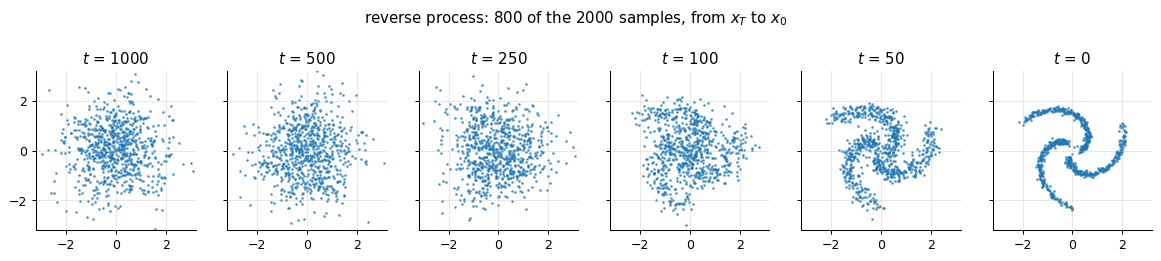

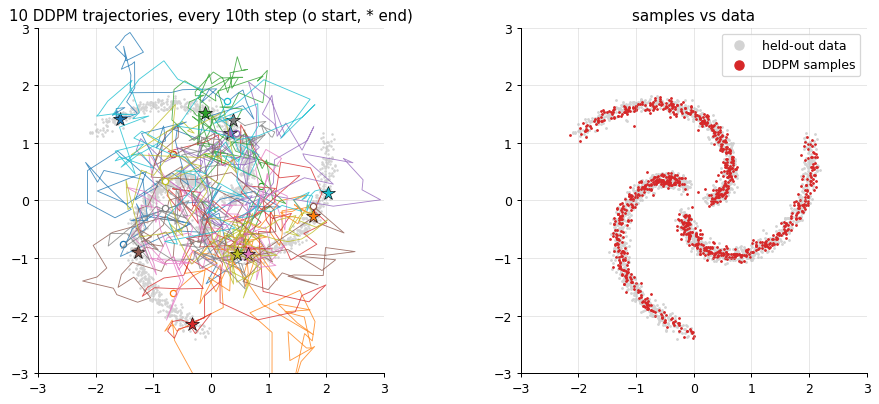

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(16, 3.0), sharex=True, sharey=True)
for ax, t in zip(axes, frames):
    ax.scatter(*traj[t][:800].T, s=1.5, c="C0", alpha=0.6)
    ax.set_title(f"$t$ = {t}"); ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
fig.suptitle("reverse process: 800 of the 2000 samples, from $x_T$ to $x_0$", y=1.02)
plt.show()

_, full = sample_ddpm(model, (10, 2), seed=1, keep=range(1, T + 1))
path = torch.stack([full[t] for t in range(T, 0, -10)] + [full[0]])          # every 10th step: (101, 10, 2)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
axes[0].scatter(*X_te.T, s=1, c="lightgray")
for k in range(10):
    axes[0].plot(*path[:, k].T, lw=0.7, alpha=0.8, color=f"C{k}")
    axes[0].plot(*path[0, k], "o", ms=5, mfc="white", color=f"C{k}")
    axes[0].plot(*path[-1, k], "*", ms=11, color=f"C{k}", mec="k", mew=0.5)
axes[0].set_title("10 DDPM trajectories, every 10th step (o start, * end)")
axes[1].scatter(*X_te.T, s=1.5, c="lightgray", label="held-out data")
axes[1].scatter(*samples[:1000].T, s=1.5, c="C3", label="DDPM samples")
axes[1].legend(markerscale=6); axes[1].set_title("samples vs data")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
plt.tight_layout(); plt.show()

**Things to notice.** The film of section 1 runs backwards: the Gaussian blob of $t = 1000$ shrinks, the arms appear between $t = 250$ and $t = 100$, and the last 50 steps sharpen them. The trajectories are random walks: every step adds fresh noise $\sigma_t\mathbf{z}$, so a point wanders a lot at the beginning, where the noise is large, before it settles on an arm. Section 7 removes this noise.

## 6. Denoising is score estimation; Langevin dynamics

The **score** of a density $p$ is $\nabla_{\mathbf{x}}\log p(\mathbf{x})$: a vector field that points towards higher density. Let $p_t$ be the distribution of $\mathbf{x}_t$: the data, shrunk by $\sqrt{\bar\alpha_t}$ and blurred by noise of variance $1-\bar\alpha_t$.

**Claim (Tweedie's formula).** $\displaystyle \nabla_{\mathbf{x}}\log p_t(\mathbf{x}_t) = -\frac{\mathbb{E}[\boldsymbol\epsilon\mid\mathbf{x}_t]}{\sqrt{1-\bar\alpha_t}}$, where $\boldsymbol\epsilon$ is the noise that produced $\mathbf{x}_t$.

*Proof.* $p_t(\mathbf{x}) = \int q(\mathbf{x}\mid\mathbf{x}_0)\,p(\mathbf{x}_0)\,d\mathbf{x}_0$. For the Gaussian $q$, $\ \nabla_{\mathbf{x}}\, q(\mathbf{x}\mid\mathbf{x}_0) = q(\mathbf{x}\mid\mathbf{x}_0)\,\frac{\sqrt{\bar\alpha_t}\,\mathbf{x}_0 - \mathbf{x}}{1-\bar\alpha_t} = -\,q(\mathbf{x}\mid\mathbf{x}_0)\,\frac{\boldsymbol\epsilon}{\sqrt{1-\bar\alpha_t}}$, with $\boldsymbol\epsilon = (\mathbf{x} - \sqrt{\bar\alpha_t}\,\mathbf{x}_0)/\sqrt{1-\bar\alpha_t}$. Differentiate under the integral and divide by $p_t(\mathbf{x})$:
$\nabla\log p_t(\mathbf{x}) = -\int \frac{q(\mathbf{x}\mid\mathbf{x}_0)\,p(\mathbf{x}_0)}{p_t(\mathbf{x})}\,\frac{\boldsymbol\epsilon}{\sqrt{1-\bar\alpha_t}}\,d\mathbf{x}_0$. The fraction is the posterior $p(\mathbf{x}_0\mid\mathbf{x})$, so the integral is a conditional expectation. $\square$

The minimiser of the mean squared error $\mathbb{E}\|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\mathbf{x}_t, t)\|^2$ is the conditional mean $\mathbb{E}[\boldsymbol\epsilon\mid\mathbf{x}_t]$, as for any regression. Hence a trained noise predictor is a score estimator:

$$ \boldsymbol\epsilon_\theta(\mathbf{x}_t, t) \approx -\sqrt{1-\bar\alpha_t}\;\nabla_{\mathbf{x}}\log p_t(\mathbf{x}_t). $$

Diffusion models and **score-based models** (Song and Ermon, 2019) are one family.

**The exact score of our training set.** For a finite training set $p_t$ is a mixture of 4000 Gaussians, $p_t(\mathbf{x}) = \frac1N\sum_i\mathcal{N}\big(\mathbf{x};\ \sqrt{\bar\alpha_t}\,\mathbf{x}^{(i)},\ (1-\bar\alpha_t)\mathbf{I}\big)$, and its score can be computed: a softmax-weighted average of the directions towards the shrunk training points. We compare it with $-\boldsymbol\epsilon_\theta/\sqrt{1-\bar\alpha_t}$ at noisy held-out points, the places where the sampler actually goes.

   t   cosine(learned, exact) median   relative error median    (at points x_t ~ q(x_t))
  20                          0.991                    0.211
 100                          0.999                    0.082
 300                          1.000                    0.008
 700                          1.000                    0.003


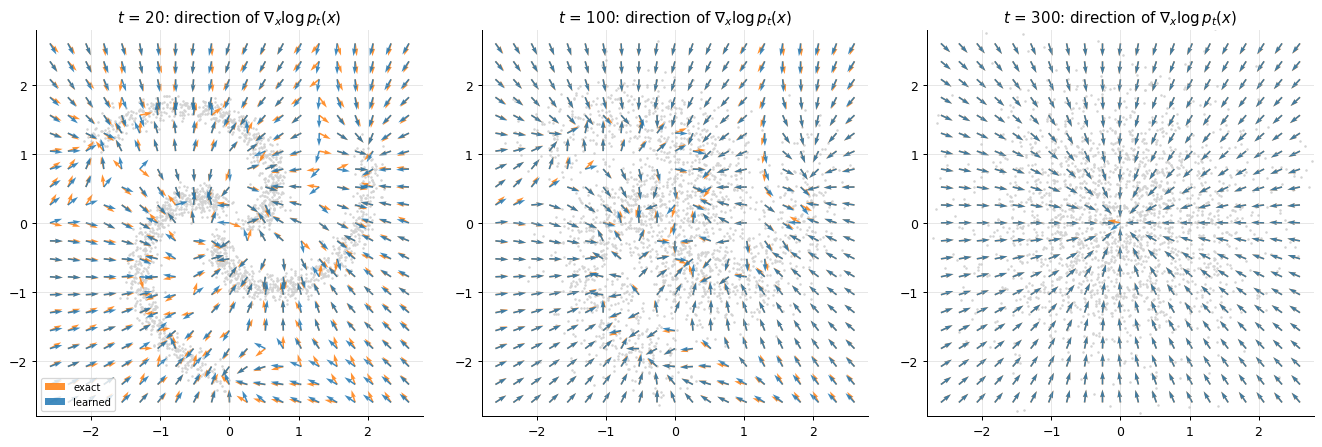

In [12]:
@torch.no_grad()
def exact_score(x, t, data=X_tr):
    """Score of p_t = (1/N) sum_i N(sqrt(abar_t) x_i, (1 - abar_t) I): the noised training set, exactly."""
    m, v = math.sqrt(abar[t]) * data, 1 - abar[t]
    wgt = torch.softmax(-torch.cdist(x, m) ** 2 / (2 * v), dim=1)       # posterior weight of every training point
    return (wgt @ m - x) / v

@torch.no_grad()
def learned_score(model, x, t):
    return -predict_eps(model, x, t) / math.sqrt(1 - abar[t])

gen = torch.Generator().manual_seed(9)
print("   t   cosine(learned, exact) median   relative error median    (at points x_t ~ q(x_t))")
for t in [20, 100, 300, 700]:
    xt = math.sqrt(abar[t]) * X_te + math.sqrt(1 - abar[t]) * torch.randn(X_te.shape, generator=gen)
    s_l, s_e = learned_score(model, xt, t), exact_score(xt, t)
    cos = F.cosine_similarity(s_l, s_e, dim=1)
    rel = (s_l - s_e).norm(dim=1) / s_e.norm(dim=1)
    print(f"{t:4d}   {cos.median():28.3f}   {rel.median():22.3f}")

g1 = torch.linspace(-2.6, 2.6, 21)
grid = torch.stack(torch.meshgrid(g1, g1, indexing="xy"), dim=-1).reshape(-1, 2)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, t in zip(axes, [20, 100, 300]):
    xt = math.sqrt(abar[t]) * X_te + math.sqrt(1 - abar[t]) * torch.randn(X_te.shape, generator=gen)
    ax.scatter(*xt.T, s=1, c="lightgray")
    for s, col, lab in [(exact_score(grid, t), "C1", "exact"), (learned_score(model, grid, t), "C0", "learned")]:
        u = s / (s.norm(dim=1, keepdim=True) + 1e-9)                  # directions only (the norms vary 100-fold)
        ax.quiver(grid[:, 0], grid[:, 1], u[:, 0], u[:, 1], color=col, scale=30, width=0.004, label=lab, alpha=0.85)
    ax.set_aspect("equal"); ax.set_xlim(-2.8, 2.8); ax.set_ylim(-2.8, 2.8)
    ax.set_title(fr"$t$ = {t}: direction of $\nabla_x\log p_t(x)$")
axes[0].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

**Interpretation.**
- The learned score points the right way almost everywhere: median cosine similarity 0.991 at $t = 20$ and at least 0.999 from $t = 100$ on. Its length is less accurate at small $t$ (median relative error 21% at $t = 20$, 0.8% at $t = 300$): there $p_t$ is a thin ridge along each arm, and its score is large and changes fast.
- In the plots (directions only) the arrows point to the nearest arm when $t$ is small, and towards the centre of the cloud when $t$ is large: at $t = 300$, $p_t$ is already close to a Gaussian blob.
- We do not want the exact score of the training set, though. Sampling with it would only reproduce the 4000 training points (exercise 6). The network is smoother than the exact score, and that is why it generates new points.

**Langevin dynamics.** If we know the score of a density $p$, we can sample from $p$ without any diffusion chain. Repeat

$$ \mathbf{x} \leftarrow \mathbf{x} + \frac{\eta}{2}\,\nabla_{\mathbf{x}}\log p(\mathbf{x}) + \sqrt{\eta}\,\mathbf{z},\qquad \mathbf{z}\sim\mathcal{N}(\mathbf{0},\mathbf{I}) . $$

The first term climbs the log-density, the noise keeps the points from collapsing onto the modes; with a small step $\eta$ and many steps the points end up distributed as $p$. Far from the data the score of a sharp $p$ is poorly estimated, so **annealed** Langevin dynamics (Song and Ermon, 2019) starts at a very noisy level and moves down: here 7 levels from $t = 500$ to $t = 5$, 30 steps each, with $\eta = 0.1\,(1-\bar\alpha_t)$.

annealed Langevin (7 noise levels x 30 steps = 210 network calls): distance to the data 0.0363, from the data 0.0238


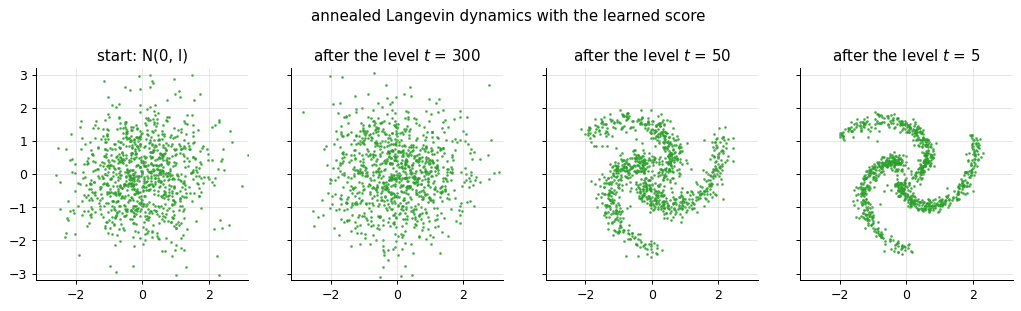

In [13]:
@torch.no_grad()
def annealed_langevin(model, n, levels=(500, 300, 200, 100, 50, 20, 5), n_steps=30, step=0.1, seed=10):
    """Langevin dynamics x <- x + (eta/2) score + sqrt(eta) z, with the learned score, from large to small noise."""
    gen = torch.Generator().manual_seed(seed)
    x = torch.randn(n, 2, generator=gen)
    snaps = {"start": x.clone()}
    for t in levels:
        eta = step * (1 - abar[t])                                     # step size proportional to the noise variance
        for _ in range(n_steps):
            x = x + 0.5 * eta * learned_score(model, x, t) + math.sqrt(eta) * torch.randn(n, 2, generator=gen)
        snaps[t] = x.clone()
    return x, snaps

lv, lv_snaps = annealed_langevin(model, 2000)
to, frm = quality(lv)
print(f"annealed Langevin (7 noise levels x 30 steps = 210 network calls): distance to the data {to:.4f}, from the data {frm:.4f}")

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharex=True, sharey=True)
for ax, k in zip(axes, ["start", 300, 50, 5]):
    ax.scatter(*lv_snaps[k][:1000].T, s=1.5, c="C2", alpha=0.7)
    ax.set_title("start: N(0, I)" if k == "start" else f"after the level $t$ = {k}")
    ax.set_aspect("equal"); ax.set_xlim(-3.2, 3.2); ax.set_ylim(-3.2, 3.2)
fig.suptitle("annealed Langevin dynamics with the learned score", y=1.02)
plt.show()

**What just happened?** Annealed Langevin with the same network, 210 network calls instead of 1000, also produces the spiral: distance to the data 0.0363 and from the data 0.0238, a little more scattered than DDPM (0.0213 and 0.0224). DDPM sampling is a carefully tuned version of the same idea: each reverse step is a step along the score plus noise, with step sizes given by the schedule.

## 7. DDIM: deterministic sampling with fewer steps

1000 network calls per sample is slow. **DDIM** (Song, Meng and Ermon, 2021) uses the same trained network and jumps between any two steps $t > t'$:

$$ \hat{\mathbf{x}}_0 = \frac{\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon_\theta(\mathbf{x}_t,t)}{\sqrt{\bar\alpha_t}},\qquad
\mathbf{x}_{t'} = \sqrt{\bar\alpha_{t'}}\,\hat{\mathbf{x}}_0 + \sqrt{1-\bar\alpha_{t'}-\sigma^2}\;\boldsymbol\epsilon_\theta(\mathbf{x}_t,t) + \sigma\,\mathbf{z},\qquad
\sigma = \eta\,\sqrt{\frac{1-\bar\alpha_{t'}}{1-\bar\alpha_t}}\,\sqrt{1-\frac{\bar\alpha_t}{\bar\alpha_{t'}}} . $$

Read it as: guess the clean point, then noise it again to the level $t'$, reusing the predicted noise as the direction. With $\eta = 1$ and $t' = t - 1$ it is exactly Algorithm 2 (exercise 5). With $\eta = 0$ there is no fresh noise and the sampler is **deterministic**: a given $\mathbf{x}_T$ always gives the same $\mathbf{x}_0$. DDIM is then a discretisation of an ordinary differential equation, the **probability flow ODE**, whose solutions have the same marginals $p_t$ as the noisy process, and a few large steps are enough.

We run both versions on a subsequence of $S$ steps that is denser near $t = 0$, where the details form: about $\tau_i = T(i/S)^2$, for example 10, 40, 90, …, 810, 1000 for $S = 10$. No retraining: the network is the one of section 4.

In [14]:
def timesteps(n_steps):
    """Increasing subsequence 1 <= tau_1 < ... < tau_S = T, denser near t = 0 (about quadratic)."""
    i = np.arange(1, n_steps + 1)
    return np.unique(np.maximum(i, np.round(T * (i / n_steps) ** 2).astype(int)))

@torch.no_grad()
def sample_ddim(model, shape, n_steps, eta=0.0, seed=0, x_T=None, c=None, w=0.0, clip=None):
    """The DDIM family (Song et al., 2021) on n_steps steps. eta = 0: DDIM, deterministic. eta = 1: DDPM."""
    gen = torch.Generator().manual_seed(seed)
    dev = next(model.parameters()).device
    x = (torch.randn(shape, generator=gen) if x_T is None else x_T.clone()).to(dev)
    ts = timesteps(n_steps)[::-1]
    for i, t in enumerate(ts):
        t_prev = ts[i + 1] if i + 1 < len(ts) else 0
        eps = predict_eps(model, x, int(t), c, w)
        x0_hat = (x - math.sqrt(1 - abar[t]) * eps) / math.sqrt(abar[t])
        if clip is not None:
            x0_hat = x0_hat.clamp(-clip, clip)
            eps = (x - math.sqrt(abar[t]) * x0_hat) / math.sqrt(1 - abar[t])
        sigma = eta * math.sqrt((1 - abar[t_prev]) / (1 - abar[t]) * (1 - abar[t] / abar[t_prev]))
        x = math.sqrt(abar[t_prev]) * x0_hat + math.sqrt(max(0.0, 1 - abar[t_prev] - sigma ** 2)) * eps
        if t_prev > 0 and eta > 0:
            x = x + sigma * torch.randn(shape, generator=gen).to(dev)
    return x.cpu()

# with every step and eta = 1 the family gives exactly Algorithm 2
a = sample_ddim(model, (500, 2), T, eta=1.0, seed=11)
b, _ = sample_ddpm(model, (500, 2), seed=11)
print(f"eta = 1 with all 1000 steps vs Algorithm 2, same noise: max difference {(a - b).abs().max():.1e}")
assert torch.allclose(a, b, atol=1e-3)

# DDIM is deterministic: the same x_T always gives the same x_0
xT = torch.randn(500, 2, generator=torch.Generator().manual_seed(12))
d1, d2 = sample_ddim(model, (500, 2), 50, eta=0.0, x_T=xT, seed=1), sample_ddim(model, (500, 2), 50, eta=0.0, x_T=xT, seed=2)
p1, p2 = sample_ddim(model, (500, 2), 50, eta=1.0, x_T=xT, seed=1), sample_ddim(model, (500, 2), 50, eta=1.0, x_T=xT, seed=2)
print(f"same x_T, two runs: DDIM max difference {(d1 - d2).abs().max():.1e}, DDPM max difference {(p1 - p2).abs().max():.2f}")

steps_list = [5, 10, 20, 50, 100, 1000]
res = {}
for S in steps_list:
    for eta in (1.0, 0.0):
        t0 = time.time()
        s = sample_ddim(model, (2000, 2), S, eta=eta, seed=0)
        res[S, eta] = quality(s) + (time.time() - t0,)
print("steps   DDPM (eta = 1): to / from the data      DDIM (eta = 0): to / from the data")
for S in steps_list:
    print(f"{S:5d}   {res[S, 1.0][0]:17.4f} / {res[S, 1.0][1]:.4f}   {res[S, 0.0][0]:24.4f} / {res[S, 0.0][1]:.4f}")

eta = 1 with all 1000 steps vs Algorithm 2, same noise: max difference 2.1e-05
same x_T, two runs: DDIM max difference 0.0e+00, DDPM max difference 3.88


steps   DDPM (eta = 1): to / from the data      DDIM (eta = 0): to / from the data
    5              0.0480 / 0.0426                     0.0481 / 0.0310
   10              0.0270 / 0.0283                     0.0313 / 0.0250
   20              0.0210 / 0.0249                     0.0253 / 0.0235
   50              0.0212 / 0.0230                     0.0230 / 0.0228
  100              0.0211 / 0.0220                     0.0227 / 0.0228
 1000              0.0213 / 0.0224                     0.0227 / 0.0224


**Things to notice.**
- The checks pass. With $\eta = 1$ and all 1000 steps the general update reproduces Algorithm 2 (largest difference $2\cdot10^{-5}$, float rounding). With $\eta = 0$ two runs from the same $\mathbf{x}_T$ give identical points; with $\eta = 1$ the same point can land 3.88 away.
- **Fewer steps.** With 20 steps both samplers are close to their 1000-step quality (DDPM 0.0210 / 0.0249, DDIM 0.0253 / 0.0235; real points 0.0217 / 0.0219): a 50-fold speed-up for free. With 5 steps both degrade, DDPM more on coverage (0.0426 against 0.0310 for DDIM) and DDIM more on precision.
- On these 2-D points the two samplers are close. On large image models the DDIM paper reports a much bigger advantage for DDIM with 10 to 50 steps (CIFAR-10, CelebA). It is not a law: noise injection also corrects part of the model's errors, and with our small MNIST model (section 9) the two 50-step samplers look alike.

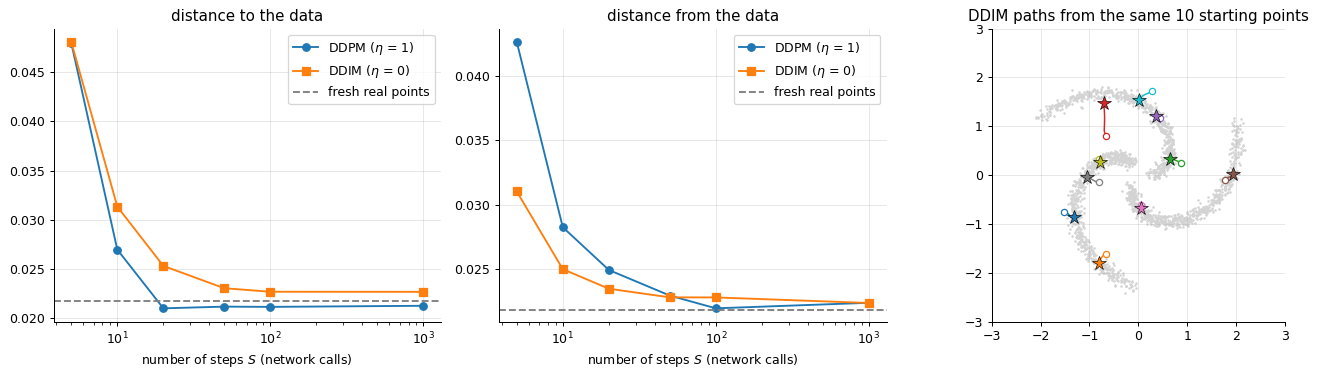

DDIM inversion with 200 steps: latent x_T has mean [-0.01 -0.1 ] and std [1.06 1.01]; mean reconstruction error 0.021 (arm spacing is about 1)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for k, lab in [(0, "distance to the data"), (1, "distance from the data")]:
    axes[k].plot(steps_list, [res[S, 1.0][k] for S in steps_list], "o-", label=r"DDPM ($\eta$ = 1)")
    axes[k].plot(steps_list, [res[S, 0.0][k] for S in steps_list], "s-", label=r"DDIM ($\eta$ = 0)")
    axes[k].axhline(quality(real)[k], color="gray", ls="--", label="fresh real points")
    axes[k].set_xscale("log"); axes[k].set_xlabel("number of steps $S$ (network calls)"); axes[k].set_title(lab); axes[k].legend()
# DDIM paths: the same 10 starting points as the DDPM trajectories of section 5, 50 deterministic steps
x = full[T].clone()
ddim_path = [x.clone()]
ts = timesteps(50)[::-1]
for i, t in enumerate(ts):
    t_prev = ts[i + 1] if i + 1 < len(ts) else 0
    eps = predict_eps(model, x, int(t))
    x0_hat = (x - math.sqrt(1 - abar[t]) * eps) / math.sqrt(abar[t])
    x = math.sqrt(abar[t_prev]) * x0_hat + math.sqrt(1 - abar[t_prev]) * eps
    ddim_path.append(x.clone())
ddim_path = torch.stack(ddim_path)
axes[2].scatter(*X_te.T, s=1, c="lightgray")
for k in range(10):
    axes[2].plot(*ddim_path[:, k].T, lw=1.2, color=f"C{k}")
    axes[2].plot(*ddim_path[0, k], "o", ms=5, mfc="white", color=f"C{k}")
    axes[2].plot(*ddim_path[-1, k], "*", ms=11, color=f"C{k}", mec="k", mew=0.5)
axes[2].set_aspect("equal"); axes[2].set_xlim(-3, 3); axes[2].set_ylim(-3, 3)
axes[2].set_title("DDIM paths from the same 10 starting points")
plt.tight_layout(); plt.show()

# DDIM as a deterministic encoder: run the same update upwards, x_0 -> x_T, then decode back
@torch.no_grad()
def ddim_invert(model, x0, n_steps):
    x, ts = x0.clone(), timesteps(n_steps)
    t_from = 0
    for t in ts:
        eps = predict_eps(model, x, int(max(t_from, 1)))              # the noise estimated at the current level
        x0_hat = (x - math.sqrt(1 - abar[t_from]) * eps) / math.sqrt(abar[t_from])     # = x when t_from = 0
        x = math.sqrt(abar[t]) * x0_hat + math.sqrt(1 - abar[t]) * eps
        t_from = t
    return x
z = ddim_invert(model, X_te[:500], 200)
rec = sample_ddim(model, (500, 2), 200, eta=0.0, x_T=z)
print(f"DDIM inversion with 200 steps: latent x_T has mean {z.mean(0).numpy().round(2)} and std {z.std(0).numpy().round(2)}; "
      f"mean reconstruction error {(rec - X_te[:500]).norm(dim=1).mean():.3f} (arm spacing is about 1)")

**What just happened?**
- The DDIM paths (right) are short, smooth curves: with no injected noise every step follows the current estimate of the noise, and the deterministic map moves each starting point to a nearby point of the spiral. The DDPM trajectories from the same 10 starting points (section 5) wandered over the plane and ended elsewhere.
- Since DDIM is a deterministic map from $\mathbf{x}_T$ to $\mathbf{x}_0$, it can be run **backwards**. Running the same update upwards encodes 500 held-out points into latents with mean $(-0.01, -0.10)$ and standard deviation $(1.06, 1.01)$, that is, Gaussian noise; decoding them returns the points with a mean error of 0.021 (the arms are about 1 apart). This **DDIM inversion** is the basis of image editing with diffusion models: invert a real photo, change the condition, decode.

## 8. Classifier-free guidance

To generate a chosen class $c$ (a digit, an arm, a text prompt), give $c$ to the network: $\boldsymbol\epsilon_\theta(\mathbf{x}_t, t, c)$. Here $c$ is the arm, embedded as a learned vector and added to the time embedding.

**Classifier-free guidance** (Ho and Salimans, 2021) trains one network for both cases: during training the label is replaced by a special "no label" token $\varnothing$ with probability 0.2. At sampling time we extrapolate from the unconditional prediction past the conditional one:

$$ \tilde{\boldsymbol\epsilon} = (1+w)\,\boldsymbol\epsilon_\theta(\mathbf{x}_t,t,c) - w\,\boldsymbol\epsilon_\theta(\mathbf{x}_t,t,\varnothing). $$

$w = 0$ is the plain conditional model. In terms of scores ($\boldsymbol\epsilon \propto -\nabla\log p$, section 6), and with Bayes, $\nabla\log p_t(\mathbf{x}\mid c) - \nabla\log p_t(\mathbf{x}) = \nabla\log p_t(c\mid\mathbf{x})$:

$$ (1+w)\,\nabla\log p_t(\mathbf{x}\mid c) - w\,\nabla\log p_t(\mathbf{x}) = \nabla\log p_t(\mathbf{x}\mid c) + w\,\nabla\log p_t(c\mid\mathbf{x}) . $$

Guidance adds $w$ times the gradient of an **implicit classifier**: it pushes the samples towards points that are not only likely under class $c$ but also clearly of class $c$. (Stable Diffusion writes the same rule with the scale $s = 1 + w$; its default $s = 7.5$ is $w = 6.5$.)

In [16]:
torch.manual_seed(1)
cond_model = NoisePredictor(n_classes=3)
t0 = time.time()
losses_c = train_toy(cond_model, p_uncond=0.2, seed=1)
print(f"conditional model: {time.time() - t0:.0f} s, loss last 500 steps {losses_c[-500:].mean():.3f} "
      f"(unconditional model: {losses[-500:].mean():.3f})")

def arm_stats(S, c):
    """Share of samples on arm c, distance to arm c's data, distance from arm c's data, mean radius."""
    on = (y_te[torch.cdist(S, X_te).argmin(1)] == c).float().mean().item()
    ref = X_te[y_te == c]
    return on, nn_dist(S, ref), nn_dist(ref, S), S.norm(dim=1).mean().item()

ws = [0, 1, 3, 8]
cfg = {}
for w in ws:
    cfg[w], _ = sample_ddpm(cond_model, (1000, 2), seed=3, c=0, w=w)
free, _ = sample_ddpm(cond_model, (1000, 2), seed=3, c=3)                # c = 3: "no label", unconditional
print("data of arm 0: mean radius", round(X_te[y_te == 0].norm(dim=1).mean().item(), 3))
print("   w   on arm 0   to arm 0   from arm 0   mean radius")
for w in ws:
    on, to, frm, rad = arm_stats(cfg[w], 0)
    print(f"{w:4}   {on:8.3f}   {to:8.4f}   {frm:10.4f}   {rad:11.3f}")
print("no label (c = ∅): distance to / from all the data", np.round(quality(free), 4))

conditional model: 37 s, loss last 500 steps 0.170 (unconditional model: 0.234)


data of arm 0: mean radius 1.335
   w   on arm 0   to arm 0   from arm 0   mean radius
   0      1.000     0.0220       0.0181         1.293
   1      1.000     0.0214       0.0198         1.482
   3      1.000     0.0218       0.0254         1.631
   8      1.000     0.0260       0.0430         1.731
no label (c = ∅): distance to / from all the data [0.024 0.032]


**Things to notice.**
- Conditioning makes the task easier: the conditional model's loss is 0.170, against 0.234 for the unconditional one, because knowing the arm removes most of the doubt about $\mathbf{x}_0$.
- Even without guidance ($w = 0$) every sample lands on arm 0. As $w$ grows the samples move outwards along the arm: mean radius 1.29, 1.48, 1.63 and 1.73 for $w$ = 0, 1, 3 and 8 (the arm's data: 1.335). They go where the point is most clearly of arm 0, far from the centre, where the three arms are close. The coverage of the arm gets worse (distance from the arm's data 0.018, 0.020, 0.025, 0.043): **guidance trades diversity for typicality**.
- With $c = \varnothing$ the same network samples all three arms (0.024 / 0.032), a little less sharply than the dedicated unconditional model, which saw five times more unconditional examples.

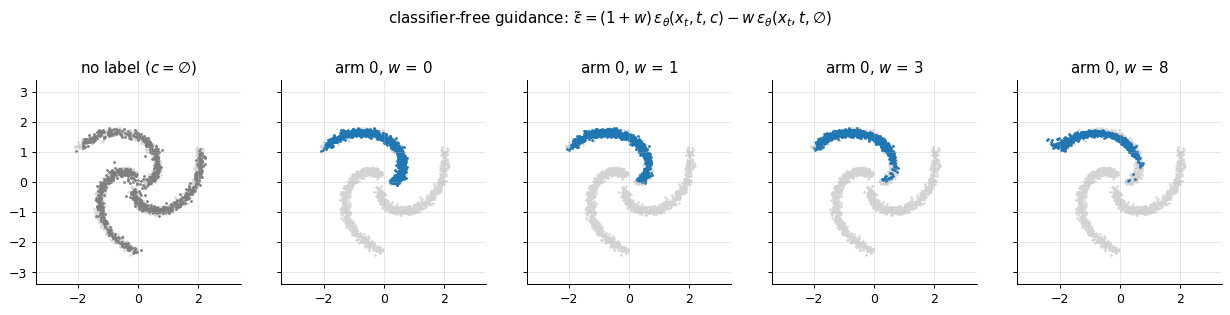

In [17]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.6), sharex=True, sharey=True)
axes[0].scatter(*X_te.T, s=1, c="lightgray"); axes[0].scatter(*free.T, s=1.5, c="C7")
axes[0].set_title(r"no label ($c=\varnothing$)")
for ax, w in zip(axes[1:], ws):
    ax.scatter(*X_te.T, s=1, c="lightgray"); ax.scatter(*cfg[w].T, s=1.5, c="C0")
    ax.set_title(f"arm 0, $w$ = {w}")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xlim(-3.4, 3.4); ax.set_ylim(-3.4, 3.4)
fig.suptitle(r"classifier-free guidance: $\tilde\epsilon=(1+w)\,\epsilon_\theta(x_t,t,c)-w\,\epsilon_\theta(x_t,t,\varnothing)$", y=1.03)
plt.show()

**Interpretation.** This is the trade-off that users of text-to-image models set with the guidance scale. A low $w$ gives varied images that sometimes ignore the prompt; a high $w$ gives images that follow the prompt closely but look alike, and at very high $w$ over-saturated and over-sharpened, as the drift of the $w = 8$ samples beyond the end of the arm suggests. Each guided step costs two network calls (with and without the label), usually batched together.

## 9. MNIST with a mini U-Net

Now images. A U-Net at $28\times28$ trains too slowly on a CPU for a lab, so we downsample MNIST to $16\times16$ (averaging blocks of pixels) and scale the pixels to $[-1, 1]$. The algorithm does not change: every pixel gets its own noise, and the network predicts a noise image of the same shape.

In [18]:
def load_mnist(train):
    ds = torchvision.datasets.MNIST("data", train=train, download=True)
    x = ds.data.float().div(255).unsqueeze(1)                     # (N, 1, 28, 28) in [0, 1]
    x = F.interpolate(x, size=(16, 16), mode="area")              # 16 x 16: 3 times fewer pixels, much faster on a CPU
    return x * 2 - 1, ds.targets                                  # [-1, 1], the scale of the noise

M_tr, My_tr = load_mnist(True)
M_te, My_te = load_mnist(False)
print(f"train {tuple(M_tr.shape)}, test {tuple(M_te.shape)}, pixel range [{M_tr.min():.0f}, {M_tr.max():.0f}], "
      f"mean {M_tr.mean():.3f}, std {M_tr.std():.3f}")

train (60000, 1, 16, 16), test (10000, 1, 16, 16), pixel range [-1, 1], mean -0.737, std 0.535


**The network** is a U-Net, as in segmentation (chapter 4 of the neural networks course): an encoder that halves the resolution twice ($16\to8\to4$), a decoder that doubles it back, and **skip connections** that hand the fine details of each encoder level to the decoder level of the same resolution. Each level is a residual block (GroupNorm, SiLU, $3\times3$ convolution, twice). The step $t$ enters through the same sinusoidal embedding as before, mapped by a small MLP and **added in every residual block as one bias per channel**. Real diffusion U-Nets are wider and add self-attention at the low resolutions: 35.7 million parameters for DDPM on CIFAR-10, 860 million for Stable Diffusion's.

In [19]:
class ResBlock(nn.Module):
    """GroupNorm, SiLU, 3x3 conv, + time embedding (one bias per channel), GroupNorm, SiLU, 3x3 conv, + skip."""
    def __init__(self, c_in, c_out, t_dim):
        super().__init__()
        self.n1, self.c1 = nn.GroupNorm(8, c_in), nn.Conv2d(c_in, c_out, 3, padding=1)
        self.t = nn.Linear(t_dim, c_out)
        self.n2, self.c2 = nn.GroupNorm(8, c_out), nn.Conv2d(c_out, c_out, 3, padding=1)
        self.skip = nn.Conv2d(c_in, c_out, 1) if c_in != c_out else nn.Identity()

    def forward(self, x, te):
        h = self.c1(F.silu(self.n1(x))) + self.t(te)[:, :, None, None]
        h = self.c2(F.silu(self.n2(h)))
        return h + self.skip(x)

class MiniUNet(nn.Module):
    """16x16 -> 8x8 -> 4x4 and back, with skip connections; 32 and 64 channels."""
    def __init__(self, ch=32, t_dim=128):
        super().__init__()
        self.t_dim = t_dim
        self.tmlp = nn.Sequential(nn.Linear(t_dim, t_dim), nn.SiLU(), nn.Linear(t_dim, t_dim))
        self.inc = nn.Conv2d(1, ch, 3, padding=1)
        self.d1, self.down1 = ResBlock(ch, ch, t_dim), nn.Conv2d(ch, ch, 4, 2, 1)
        self.d2, self.down2 = ResBlock(ch, 2 * ch, t_dim), nn.Conv2d(2 * ch, 2 * ch, 4, 2, 1)
        self.mid = ResBlock(2 * ch, 2 * ch, t_dim)
        self.up2, self.u2 = nn.ConvTranspose2d(2 * ch, 2 * ch, 4, 2, 1), ResBlock(4 * ch, 2 * ch, t_dim)
        self.up1, self.u1 = nn.ConvTranspose2d(2 * ch, 2 * ch, 4, 2, 1), ResBlock(3 * ch, ch, t_dim)
        self.out = nn.Sequential(nn.GroupNorm(8, ch), nn.SiLU(), nn.Conv2d(ch, 1, 3, padding=1))

    def forward(self, x, t):
        te = self.tmlp(time_embedding(t, self.t_dim))
        h1 = self.d1(self.inc(x), te)                                 # 16 x 16, 32 channels
        h2 = self.d2(self.down1(h1), te)                              # 8 x 8, 64 channels
        h = self.mid(self.down2(h2), te)                              # 4 x 4, 64 channels
        h = self.u2(torch.cat([self.up2(h), h2], dim=1), te)          # 8 x 8, skip from h2
        h = self.u1(torch.cat([self.up1(h), h1], dim=1), te)          # 16 x 16, skip from h1
        return self.out(h)

torch.manual_seed(0)
unet = MiniUNet().to(device)
print(f"mini U-Net: {sum(p.numel() for p in unet.parameters()):,} parameters")
with torch.no_grad():
    print("output shape:", tuple(unet(M_tr[:4].to(device), torch.tensor([1, 10, 100, 1000], device=device)).shape),
          "(same as the input: one noise value per pixel)")

mini U-Net: 590,049 parameters
output shape: (4, 1, 16, 16) (same as the input: one noise value per pixel)


**Training**: Algorithm 1 with batches of 128 images, 2000 steps, Adam with learning rate $2\cdot10^{-3}$, and an **exponential moving average** (EMA) of the weights, $\theta_{\text{EMA}} \leftarrow 0.995\,\theta_{\text{EMA}} + 0.005\,\theta$, used for sampling. The EMA is standard for diffusion models: it averages out the noise of the last updates and gives visibly cleaner samples. This is the slow cell: about 4 minutes on a 4-thread CPU, seconds on a GPU.

In [20]:
abar_dev = abar_t.to(device)
ema = copy.deepcopy(unet)                                             # exponential moving average of the weights
opt = torch.optim.Adam(unet.parameters(), lr=2e-3)
gen = torch.Generator().manual_seed(0)
steps, batch = 2000, 128
m_losses = []
t0 = time.time()
for step in range(1, steps + 1):
    idx = torch.randint(0, len(M_tr), (batch,), generator=gen)
    x0 = M_tr[idx].to(device)
    t = torch.randint(1, T + 1, (batch,), generator=gen).to(device)
    eps = torch.randn(x0.shape, generator=gen).to(device)
    ab = abar_dev[t][:, None, None, None]
    loss = F.mse_loss(unet(ab.sqrt() * x0 + (1 - ab).sqrt() * eps, t), eps)
    opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        d = min(0.995, (1 + step) / (10 + step))                      # EMA decay, with a warm-up
        for pe, p in zip(ema.parameters(), unet.parameters()):
            pe.mul_(d).add_(p, alpha=1 - d)
    m_losses.append(loss.item())
    if step % 500 == 0:
        print(f"step {step:5d}: loss (last 500 steps) {np.mean(m_losses[-500:]):.4f}, {time.time() - t0:.0f} s")
m_losses = np.array(m_losses)
print(f"{steps} steps x {batch} images = {steps * batch / len(M_tr):.1f} epochs in {(time.time() - t0) / 60:.1f} min")
ema.eval()

step   500: loss (last 500 steps) 0.0678, 59 s


step  1000: loss (last 500 steps) 0.0410, 119 s


step  1500: loss (last 500 steps) 0.0381, 177 s


step  2000: loss (last 500 steps) 0.0360, 233 s
2000 steps x 128 images = 4.3 epochs in 3.9 min


MiniUNet(
  (tmlp): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
  )
  (inc): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (d1): ResBlock(
    (n1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (c1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (t): Linear(in_features=128, out_features=32, bias=True)
    (n2): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (c2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (skip): Identity()
  )
  (down1): Conv2d(32, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
  (d2): ResBlock(
    (n1): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (c1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (t): Linear(in_features=128, out_features=64, bias=True)
    (n2): GroupNorm(8, 64, eps=1e-05, affine=True, bias=True)
    (c2): Co

**Things to notice.** The loss drops from 1 (a network that predicts 0) to 0.068 on average over the first 500 steps, then slowly to 0.036 over steps 1501–2000: per pixel, 96% of the noise variance is explained. It is still falling, so more training would help. 2000 steps of 128 images are 4.3 passes over the training set, in 3.9 minutes here. The DDPM paper trained its CIFAR-10 model for 800,000 steps.

**What does the network see?** Take test digits, add noise at level $t$, and look at the network's estimate of the clean image, $\hat{\mathbf{x}}_0 = (\mathbf{x}_t - \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon_\theta)/\sqrt{\bar\alpha_t}$, clipped to the pixel range. We also measure its mean squared error on 2000 test digits, against the simplest guess: the average training image.

    t   MSE of x0_hat (2000 test digits)   MSE of the mean image


   50                             0.004                  0.169


  200                             0.030                  0.169


  400                             0.109                  0.169


  600                             0.168                  0.169


  800                             0.261                  0.169


  950                             0.813                  0.169


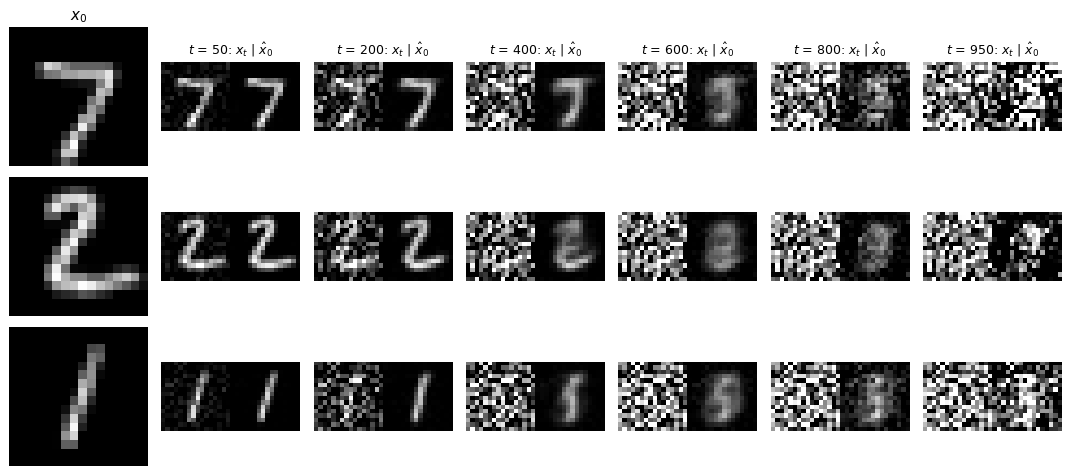

In [21]:
@torch.no_grad()
def x0_from_eps(model, xt, t):
    eps = model(xt, torch.full((len(xt),), t, device=xt.device))
    return (xt - math.sqrt(1 - abar[t]) * eps) / math.sqrt(abar[t])

show_t = [50, 200, 400, 600, 800, 950]
x0 = M_te[:6].to(device)
gen = torch.Generator().manual_seed(13)
noise = torch.randn(x0.shape, generator=gen).to(device)
mean_img = M_tr.mean(0, keepdim=True).to(device)
fig, axes = plt.subplots(3, 7, figsize=(12, 5.4))
for r in range(3):
    axes[r, 0].imshow(x0[r, 0].cpu(), cmap="gray", vmin=-1, vmax=1); axes[r, 0].set_title("$x_0$" if r == 0 else "")
print("    t   MSE of x0_hat (2000 test digits)   MSE of the mean image")
for j, t in enumerate(show_t):
    xt = math.sqrt(abar[t]) * x0 + math.sqrt(1 - abar[t]) * noise
    x0h = x0_from_eps(ema, xt, t).clamp(-1, 1)
    for r in range(3):
        axes[r, j + 1].imshow(torch.cat([xt[r, 0], x0h[r, 0]], dim=1).cpu(), cmap="gray", vmin=-1, vmax=1)
    axes[0, j + 1].set_title(f"$t$ = {t}: $x_t$ | $\\hat x_0$", fontsize=10)
    xb = M_te[:2000].to(device)
    nb = torch.randn(xb.shape, generator=gen).to(device)
    xbt = math.sqrt(abar[t]) * xb + math.sqrt(1 - abar[t]) * nb
    mse = ((x0_from_eps(ema, xbt, t).clamp(-1, 1) - xb) ** 2).mean().item()
    print(f"{t:5d}   {mse:31.3f}   {((mean_img - xb) ** 2).mean().item():20.3f}")
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout(); plt.show()

**Interpretation.**
- For small and medium $t$ the network's guess of the clean digit is very good, even where $\mathbf{x}_t$ is hard to read: MSE 0.004 at $t = 50$ and 0.030 at $t = 200$, against 0.169 for the average image. At $t = 400$ (MSE 0.109) the digit is blurred but mostly recognisable.
- From $t \approx 600$ on, $\hat{\mathbf{x}}_0$ is a blurry average of plausible digits, and at $t = 800$ and $950$ (MSE 0.261 and 0.813) it is even worse than the average image. A perfect network would never be: the best guess $\mathbb{E}[\mathbf{x}_0 \mid \mathbf{x}_t]$ tends to the average image as the signal disappears. Our short training shows here, where $\sqrt{\bar\alpha_t}$ (0.039 at $t = 800$) amplifies every error of $\boldsymbol\epsilon_\theta$, as in section 4.
- This is the picture to keep: the network is a good **denoiser** long before it is a good **generator**. Generation chains 1000 such guesses starting from pure noise, so the errors of the noisy end matter most.

**Sampling.** DDPM with all 1000 steps; and, from one common $\mathbf{x}_T$, the stochastic sampler ($\eta$ = 1) and DDIM ($\eta$ = 0) with 50 steps each. For images we clip $\hat{\mathbf{x}}_0$ to $[-1, 1]$ at every step (and recompute the noise from the clipped $\hat{\mathbf{x}}_0$). A pixel cannot be brighter than white, and without the clip the first, very uncertain steps, where $\hat{\mathbf{x}}_0$ is worst (section 4), push pixels out of range.

64 samples: DDPM 1000 steps 15.5 s, DDIM 50 steps 0.8 s (18 times faster)


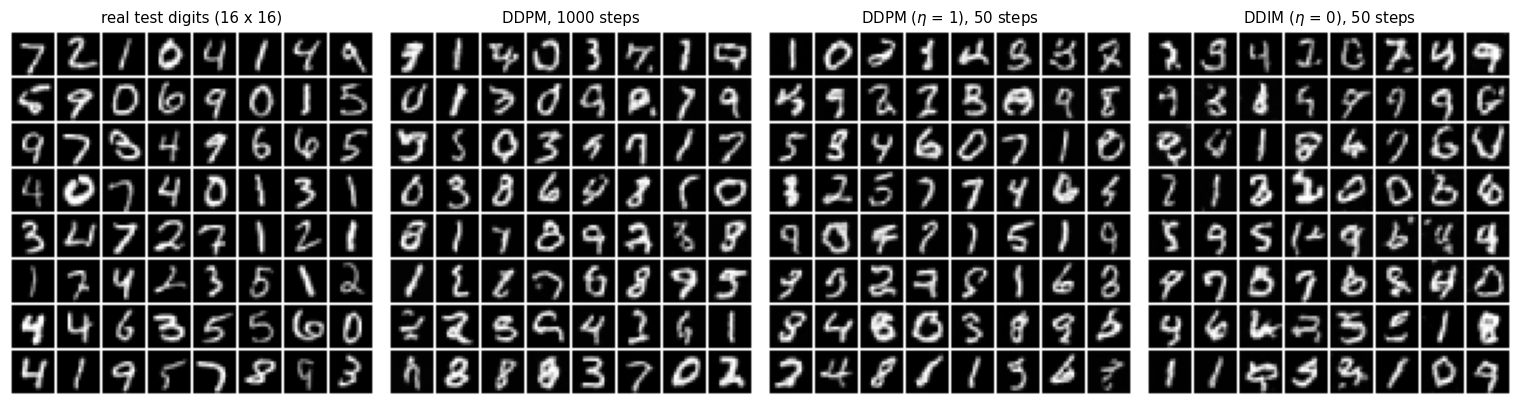

distance of each sample to its nearest training digit: median 3.93 (a real test digit: median 2.99); not copies of the training set


In [22]:
def show_grid(ax, imgs, title, nrow=8):
    g = torchvision.utils.make_grid((imgs.clamp(-1, 1) + 1) / 2, nrow=nrow, padding=1, pad_value=1)
    ax.imshow(g.permute(1, 2, 0)); ax.set_title(title); ax.axis("off")

t0 = time.time()
mn_ddpm, _ = sample_ddpm(ema, (64, 1, 16, 16), seed=14, clip=1.0)
t_ddpm = time.time() - t0
xT = torch.randn((64, 1, 16, 16), generator=torch.Generator().manual_seed(15))
t0 = time.time()
mn_ddim = sample_ddim(ema, (64, 1, 16, 16), 50, eta=0.0, x_T=xT, clip=1.0)
t_ddim = time.time() - t0
mn_ddpm50 = sample_ddim(ema, (64, 1, 16, 16), 50, eta=1.0, x_T=xT, seed=16, clip=1.0)
print(f"64 samples: DDPM 1000 steps {t_ddpm:.1f} s, DDIM 50 steps {t_ddim:.1f} s ({t_ddpm / t_ddim:.0f} times faster)")

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
show_grid(axes[0], M_te[:64], "real test digits (16 x 16)")
show_grid(axes[1], mn_ddpm, "DDPM, 1000 steps")
show_grid(axes[2], mn_ddpm50, r"DDPM ($\eta$ = 1), 50 steps")
show_grid(axes[3], mn_ddim, r"DDIM ($\eta$ = 0), 50 steps")
plt.tight_layout(); plt.show()

near = torch.cdist(mn_ddpm.flatten(1), M_tr.flatten(1)).min(1).values
near_te = torch.cdist(M_te[:64].flatten(1), M_tr.flatten(1)).min(1).values
print(f"distance of each sample to its nearest training digit: median {near.median():.2f} "
      f"(a real test digit: median {near_te.median():.2f}); not copies of the training set")

**Be honest about the quality.** After 4 minutes of training on a CPU, many samples are recognisable digits (0, 1, 3, 4, 6, 7, 8, 9 are easy to find), and some are broken strokes that are no digit at all. That is normal for a 590,000-parameter network trained for 4.3 epochs; the same code with a wider U-Net and an hour on a GPU gives clean digits. What the figure does show:
- **The samples are new.** The median distance from a sample to its nearest training digit is 3.93, more than for a real test digit (2.99): the network is not copying its training set.
- **Fewer steps, same network.** With 50 steps instead of 1000, sampling is 18 times faster (0.8 s against 15.5 s for 64 digits) and the digits look about as good. Here the stochastic 50-step sampler ($\eta$ = 1) even shows fewer broken strokes than DDIM: with an imperfect network the fresh noise corrects part of the errors, a trade-off studied by Karras et al. (2022). On large, well-trained image models DDIM is usually the better few-step sampler.

In [23]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 6.4 min on cpu


## 10. Summary

- **Forward process**: $\mathbf{x}_t = \sqrt{1-\beta_t}\,\mathbf{x}_{t-1} + \sqrt{\beta_t}\,\boldsymbol\epsilon$, variance preserving; closed form $\mathbf{x}_t = \sqrt{\bar\alpha_t}\,\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\,\boldsymbol\epsilon$ (proof by induction; 100,000 chains agree: 1.8932 vs 1.8942 at $t = 100$). Linear schedule: SNR 1 at $t = 260$ and 33% of the steps in almost pure noise; cosine: $t = 497$ and 6%.
- **Posterior**: $q(\mathbf{x}_{t-1}\mid\mathbf{x}_t,\mathbf{x}_0) = \mathcal{N}(\tilde{\boldsymbol\mu}_t, \tilde\beta_t\mathbf{I})$ with $\tilde\beta_t = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t$ and $\tilde{\boldsymbol\mu}_t = \frac{1}{\sqrt{\alpha_t}}\big(\mathbf{x}_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\boldsymbol\epsilon\big)$ (Monte Carlo: 1.6070 ± 0.0448 vs 1.6076 ± 0.0451).
- **Loss**: the ELBO is a sum of KLs between Gaussians, $\lambda_t\|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\mathbf{x}_t, t)\|^2$; DDPM drops $\lambda_t$ (which is 59 times larger at $t = 2$ than at $t = 1000$): $L_{\text{simple}} = \mathbb{E}\|\boldsymbol\epsilon - \boldsymbol\epsilon_\theta(\sqrt{\bar\alpha_t}\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\boldsymbol\epsilon, t)\|^2$.
- **Toy model**: a residual MLP with a sinusoidal time embedding in every block (120,450 parameters, 8000 steps, under a minute); loss 0.234 per coordinate; DDPM samples as close to the data as real points (0.0213 / 0.0224 against 0.0217 / 0.0219), with every arm present.
- **Score**: $\boldsymbol\epsilon_\theta(\mathbf{x}_t,t) \approx -\sqrt{1-\bar\alpha_t}\,\nabla\log p_t(\mathbf{x}_t)$ (Tweedie); median cosine with the exact score 0.991 at $t = 20$, 0.999 at $t = 100$. Annealed Langevin with the same network also samples the spiral.
- **DDIM**: $\mathbf{x}_{t'} = \sqrt{\bar\alpha_{t'}}\hat{\mathbf{x}}_0 + \sqrt{1-\bar\alpha_{t'}-\sigma^2}\,\boldsymbol\epsilon_\theta + \sigma\mathbf{z}$; $\eta = 1$ is DDPM, $\eta = 0$ is deterministic and invertible (reconstruction error 0.021). 20 steps are close to 1000 on the toy data.
- **Classifier-free guidance**: $\tilde{\boldsymbol\epsilon} = (1+w)\boldsymbol\epsilon_\theta(\mathbf{x}_t,t,c) - w\,\boldsymbol\epsilon_\theta(\mathbf{x}_t,t,\varnothing)$, label dropped 20% of the time in training; more $w$ = more typical, less diverse (mean radius 1.29 → 1.73, coverage distance 0.018 → 0.043 for $w$ = 0 → 8).
- **MNIST 16×16**: a mini U-Net (590,049 parameters, 3.9 minutes): excellent $\hat{\mathbf{x}}_0$ for $t \le 200$ (MSE 0.004 to 0.030), rough but new samples; 50 steps instead of 1000 are 18 times faster.

## Exercises

Try each one before opening the answer.

1. **Constant schedule.** With a constant $\beta_t = \beta$, write $\bar\alpha_t$ in closed form. For $\beta = 0.01$, at which $t$ is the SNR equal to 1? How many steps until $\sqrt{\bar\alpha_t} < 0.01$?
2. **The first step.** What are $\tilde\beta_1$ and $\tilde{\boldsymbol\mu}_1$? Why does Algorithm 2 add no noise in its last step? Show that $\tilde\beta_t \le \beta_t$ for every $t$.
3. **Predict $\mathbf{x}_0$ instead.** A network $\hat{\mathbf{x}}_\theta(\mathbf{x}_t, t)$ predicts the clean data, with loss $\|\mathbf{x}_0 - \hat{\mathbf{x}}_\theta\|^2$. Show that it is $\boldsymbol\epsilon$-prediction with a weight that depends on $t$, and give the weight. Which steps does it emphasise?
4. **Guidance as an implicit classifier.** Prove $(1+w)\nabla\log p(\mathbf{x}\mid c) - w\nabla\log p(\mathbf{x}) = \nabla\log p(\mathbf{x}\mid c) + w\nabla\log p(c\mid\mathbf{x})$. Which density would we sample if this held exactly at $t = 0$?
5. **DDIM with $\eta = 1$ is DDPM.** Show that with $t' = t - 1$ and $\eta = 1$, $\sigma^2 = \tilde\beta_t$ and the mean of the DDIM update equals $\tilde{\boldsymbol\mu}_t$ of Algorithm 2.
6. **Memorisation.** Section 6 computed the exact score of $p_t$ for the 4000 training points. What would a sampler that used this exact score produce as $t \to 0$? Why does the trained network generate new points instead? (Optional: try it with `exact_score` in place of the network.)
7. **Latent diffusion arithmetic.** Stable Diffusion runs on $64\times64\times4$ latents instead of $512\times512\times3$ images. By how much does this reduce the number of values per step? A self-attention layer over all positions of a $64\times64$ feature map costs $O(n^2)$ in the number $n$ of positions; how much more would it cost at $512\times512$?

<details>
<summary><b>Answers</b></summary>

**1.** $\bar\alpha_t = (1-\beta)^t$. SNR = 1 means $\bar\alpha_t = 1/2$: $t = \ln 0.5/\ln 0.99 = 69$ steps. $\sqrt{\bar\alpha_t} < 0.01$ means $\bar\alpha_t < 10^{-4}$: $t > \ln 10^{-4}/\ln 0.99 = 916.4$, so 917 steps. With a constant $\beta$ the SNR falls exponentially from the first step; growing schedules (linear, cosine) keep the first steps gentle.

**2.** $\bar\alpha_0 = 1$, so $\tilde\beta_1 = \frac{1-1}{1-\bar\alpha_1}\beta_1 = 0$ and $\tilde{\boldsymbol\mu}_1 = \frac{\sqrt{1}\,\beta_1}{1-\bar\alpha_1}\mathbf{x}_0 + 0 = \mathbf{x}_0$ (since $1 - \bar\alpha_1 = \beta_1$). Given $\mathbf{x}_0$, the step back from $\mathbf{x}_1$ is certain: it is $\mathbf{x}_0$. The last step of Algorithm 2 returns its best estimate of that mean and adds no noise, which would only blur the result. $\tilde\beta_t \le \beta_t$ because $\bar\alpha_t = \alpha_t\bar\alpha_{t-1} \le \bar\alpha_{t-1}$, so $1-\bar\alpha_{t-1} \le 1-\bar\alpha_t$ and the factor $\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}$ is at most 1: knowing $\mathbf{x}_0$ can only reduce the uncertainty. Section 3 printed the factor: 0.853 at $t = 10$, 0.982 at $t = 100$.

**3.** From $\mathbf{x}_t = \sqrt{\bar\alpha_t}\mathbf{x}_0 + \sqrt{1-\bar\alpha_t}\boldsymbol\epsilon$, any prediction $\hat{\mathbf{x}}$ of $\mathbf{x}_0$ defines a prediction of the noise $\hat{\boldsymbol\epsilon} = (\mathbf{x}_t - \sqrt{\bar\alpha_t}\hat{\mathbf{x}})/\sqrt{1-\bar\alpha_t}$, and $\mathbf{x}_0 - \hat{\mathbf{x}} = \frac{\sqrt{1-\bar\alpha_t}}{\sqrt{\bar\alpha_t}}(\hat{\boldsymbol\epsilon} - \boldsymbol\epsilon)$. So $\|\mathbf{x}_0 - \hat{\mathbf{x}}\|^2 = \frac{1-\bar\alpha_t}{\bar\alpha_t}\|\boldsymbol\epsilon - \hat{\boldsymbol\epsilon}\|^2 = \|\boldsymbol\epsilon - \hat{\boldsymbol\epsilon}\|^2/\mathrm{SNR}(t)$: $\boldsymbol\epsilon$-prediction with weight $1/\mathrm{SNR}(t)$. It emphasises the noisy steps (large $t$, small SNR) enormously: about $2.5\cdot10^4$ at $t = 1000$ against $10^{-4}$ at $t = 1$. Section 4 measured both errors: 0.007 for $\hat{\mathbf{x}}_0$ at small $t$, 1.28 at large $t$.

**4.** Bayes: $p(c\mid\mathbf{x}) = p(\mathbf{x}\mid c)p(c)/p(\mathbf{x})$, so $\nabla_{\mathbf{x}}\log p(c\mid\mathbf{x}) = \nabla\log p(\mathbf{x}\mid c) - \nabla\log p(\mathbf{x})$ (the prior $p(c)$ does not depend on $\mathbf{x}$). Then $\nabla\log p(\mathbf{x}\mid c) + w\nabla\log p(c\mid\mathbf{x}) = (1+w)\nabla\log p(\mathbf{x}\mid c) - w\nabla\log p(\mathbf{x})$. It is the score of $\tilde p(\mathbf{x}) \propto p(\mathbf{x}\mid c)\,p(c\mid\mathbf{x})^w$: the class density, tilted towards points the implicit classifier is sure about. It holds only approximately in practice: the guided scores of the noisy levels are not the scores of the noised $\tilde p$, so the sampler does not draw exactly from $\tilde p$.

**5.** With $t' = t-1$: $\sigma^2 = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\big(1 - \frac{\bar\alpha_t}{\bar\alpha_{t-1}}\big) = \frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}(1-\alpha_t) = \tilde\beta_t$. For the mean, write $\mathbf{x}_t = \sqrt{\bar\alpha_t}\hat{\mathbf{x}}_0 + \sqrt{1-\bar\alpha_t}\boldsymbol\epsilon_\theta$ (the definition of $\hat{\mathbf{x}}_0$) in $\tilde{\boldsymbol\mu}_t = c_0\hat{\mathbf{x}}_0 + c_1\mathbf{x}_t$, with $c_0 = \frac{\sqrt{\bar\alpha_{t-1}}\beta_t}{1-\bar\alpha_t}$, $c_1 = \frac{\sqrt{\alpha_t}(1-\bar\alpha_{t-1})}{1-\bar\alpha_t}$. The coefficient of $\hat{\mathbf{x}}_0$ is $c_0 + c_1\sqrt{\bar\alpha_t} = \sqrt{\bar\alpha_{t-1}}\frac{\beta_t + \alpha_t - \bar\alpha_t}{1-\bar\alpha_t} = \sqrt{\bar\alpha_{t-1}}$. The coefficient of $\boldsymbol\epsilon_\theta$ is $c_1\sqrt{1-\bar\alpha_t}$, whose square is $\frac{\alpha_t(1-\bar\alpha_{t-1})^2}{1-\bar\alpha_t}$; and $1 - \bar\alpha_{t-1} - \tilde\beta_t = (1-\bar\alpha_{t-1})\frac{1-\bar\alpha_t-\beta_t}{1-\bar\alpha_t} = \frac{\alpha_t(1-\bar\alpha_{t-1})^2}{1-\bar\alpha_t}$, the same. So both updates have the same mean and variance; section 7 confirmed it numerically (difference $2\cdot10^{-5}$).

**6.** As $t \to 0$ the exact $p_t$ is a mixture of 4000 tiny Gaussians centred on the training points, and its score pulls every point to its nearest training point. A sampler with the exact score would return copies of the training set (with a little noise): it is the minimiser of the training loss on a finite data set, and it memorises. The network cannot represent this jagged field exactly with its smooth, limited capacity, and it is trained on fresh noise every step, so it learns a smoothed score that fills the spiral between the training points. That is why its samples were no closer to the training set (0.0151) than fresh real points (0.0157). Very large models trained on small data sets do start to memorise, a known privacy issue of image models.

**7.** $512\cdot512\cdot3 = 786{,}432$ values against $64\cdot64\cdot4 = 16{,}384$: 48 times fewer. Self-attention over all positions: $n = 64^2 = 4096$ positions in the latent against $512^2 = 262{,}144$ in pixel space, 64 times more positions and $64^2 = 4096$ times more pairs. That is why pixel-space models only attend at low resolutions, and why latent diffusion made high-resolution text-to-image generation affordable.

</details>